In [ ]:
import pandas as pd
ventas = pd.read_csv("california_housing_train.csv")
ventas.head(51)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
5,-114.58,33.63,29.0,1387.0,236.0,671.0,239.0,3.3438,74000.0
6,-114.58,33.61,25.0,2907.0,680.0,1841.0,633.0,2.6768,82400.0
7,-114.59,34.83,41.0,812.0,168.0,375.0,158.0,1.7083,48500.0
8,-114.59,33.61,34.0,4789.0,1175.0,3134.0,1056.0,2.1782,58400.0
9,-114.60,34.83,46.0,1497.0,309.0,787.0,271.0,2.1908,48100.0


In [ ]:
import yfinance as yf
amzn =  yf.download("AMZN", end = "2026-01-01")
amzn

/tmp/ipython-input-813098630.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  amzn =  yf.download("AMZN", end = "2026-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2025-12-01,233.880005,235.800003,232.250000,233.220001,42904000
2025-12-02,234.419998,238.970001,233.550003,235.009995,45785400
2025-12-03,232.380005,233.380005,230.610001,233.350006,35495100
2025-12-04,229.110001,233.500000,226.800003,232.770004,45683200
2025-12-05,229.529999,231.240005,228.550003,230.320007,33117400
2025-12-08,226.889999,230.830002,226.270004,229.589996,35019200
2025-12-09,227.919998,228.570007,225.110001,226.839996,25841700
2025-12-10,231.779999,232.419998,228.460007,228.809998,38790700


In [ ]:
precios_amz = amzn["Close"]
precios_amz.columns = ['Close'] # Renaming the multi-index column to a simple string 'Close'
precios_amz

,Close
Date,
2025-12-01,233.880005
2025-12-02,234.419998
2025-12-03,232.380005
2025-12-04,229.110001
2025-12-05,229.529999
2025-12-08,226.889999
2025-12-09,227.919998
2025-12-10,231.779999
2025-12-11,230.279999


In [ ]:
import plotly.express as px

# Reset the index so 'Date' becomes a regular column for plotly
df_plot = precios_amz.reset_index()

fig = px.line(
    df_plot,
    x=df_plot.index.name, # Use the original index name for the x-axis to maintain context, or 'Date' if reset
    y='Close',
    title='Precios de Cierre de Amazon (AMZN)',
    labels={'index': 'Fecha', 'Close': 'Precio de Cierre'}, # Customize axis labels
    color_discrete_sequence=['pink'] # Set the line color to pink
)

fig.update_layout(
    title_font_size=16,
    xaxis=dict(
        tickangle=-45, # Rotate x-axis labels for better readability
        showgrid=True, gridwidth=1, gridcolor='LightPink'
    ),
    yaxis=dict(
        showgrid=True, gridwidth=1, gridcolor='LightPink'
    )
)

fig.show()

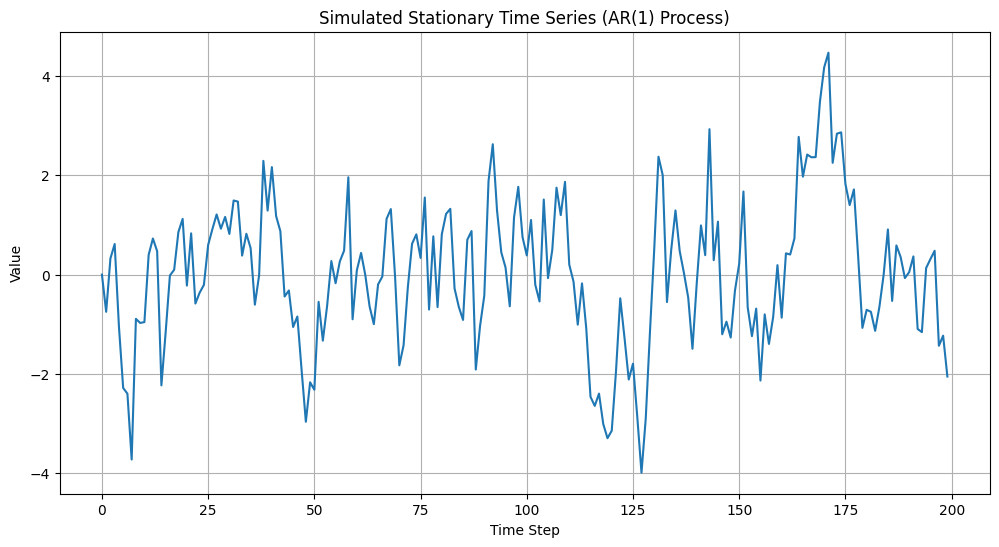

0    0.000000
1   -0.749777
2    0.324759
3    0.614698
4   -1.039520
Name: Stationary Time Series, dtype: float64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameters for the AR(1) process
# For stationarity, the absolute value of phi must be less than 1
phi = 0.7  # Autoregressive coefficient
mu = 0    # Mean of the series
sigma = 1 # Standard deviation of the white noise

# Number of data points
n_points = 200

# Initialize the time series
ts = np.zeros(n_points)

# Generate white noise (innovations)
white_noise = np.random.normal(loc=0, scale=sigma, size=n_points)

# Simulate the AR(1) process: ts[t] = mu + phi * (ts[t-1] - mu) + white_noise[t]
for i in range(1, n_points):
    ts[i] = mu + phi * (ts[i-1] - mu) + white_noise[i]

# Create a Pandas Series for better handling and plotting
stationary_ts = pd.Series(ts, name='Stationary Time Series')

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(stationary_ts)
plt.title('Simulated Stationary Time Series (AR(1) Process)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.grid(True)
plt.show()

print(stationary_ts.head())

In [ ]:
import numpy as np
import plotly.express as px

# Parámetros
np.random.seed(42)
T = 200
sigma = 1

# Shocks Z_t ~ N(0, sigma^2)
Z = np.random.normal(0, sigma, T)

# Random Walk
X = np.zeros(T)
for t in range(1, T):
    X[t] = X[t-1] + Z[t]

# Gráfica rosa
fig = px.line(
    x=np.arange(T),
    y=X,
    title="Random Walk: Xt = Xt-1 + Zt",
    labels={"x": "Tiempo (t)", "y": "X_t"}
)

# Estilo rosa
fig.update_traces(line=dict(color="#ff1493", width=3))  # rosa fuerte
fig.update_layout(
    template="plotly_white",
    plot_bgcolor="#ffe6f2",      # fondo rosa claro
    paper_bgcolor="#ffe6f2",
    font=dict(color="#cc0066", size=14),
    title_font=dict(color="#ff1493", size=20)
)

fig.show()


In [ ]:
import numpy as np
import plotly.express as px
from statsmodels.tsa.stattools import adfuller, kpss

# Parámetros
np.random.seed(42)
T = 200
sigma = 1

# Generar shocks
Z = np.random.normal(0, sigma, T)

# Random Walk
X = np.zeros(T)
for t in range(1, T):
    X[t] = X[t-1] + Z[t]

# Diferenciación
dX = np.diff(X)

# --------- GRÁFICA ROSA ---------
fig = px.line(
    x=np.arange(1, T),
    y=dX,
    title="Serie Diferenciada ΔXt",
    labels={"x": "Tiempo (t)", "y": "ΔX_t"}
)

fig.update_traces(line=dict(color="#ff1493", width=3))
fig.update_layout(
    template="plotly_white",
    plot_bgcolor="#ffe6f2",
    paper_bgcolor="#ffe6f2",
    font=dict(color="#cc0066", size=14),
    title_font=dict(color="#ff1493", size=20)
)

fig.show()

# --------- ADF TEST ---------
adf_result = adfuller(dX)

print("===== ADF TEST =====")
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

# --------- KPSS TEST ---------
kpss_result = kpss(dX, regression='c')

print("\n===== KPSS TEST =====")
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Critical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value}")


===== ADF TEST =====
ADF Statistic: -14.691774924143179
p-value: 3.0415339027296236e-27
Critical Values:
   1%: -3.4638151713286316
   5%: -2.876250632135043
   10%: -2.574611347821651

===== KPSS TEST =====
KPSS Statistic: 0.2014715187111094
p-value: 0.1
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739


/tmp/ipython-input-1979307040.py:51: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




In [ ]:
import numpy as np
import plotly.express as px

# Parámetros
np.random.seed(42)
T = 200
sigma = 1

# Ruido blanco
Z = np.random.normal(0, sigma, T)

# Crear rezago
Z_lag = np.roll(Z, 1)
Z_lag[0] = 0  # evitar basura en el primer elemento

# Modelo 1: Xt = Zt + 2Zt-1
X1 = Z + 2 * Z_lag

# Modelo 2: Xt = Zt + 0.5Zt-1
X2 = Z + 0.5 * Z_lag

# --------- GRÁFICA MODELO 1 ---------
fig1 = px.line(
    x=np.arange(T),
    y=X1,
    title="Modelo 1: Xt = Zt + 2Zt-1",
    labels={"x": "Tiempo (t)", "y": "X_t"}
)

fig1.update_traces(line=dict(color="#ff1493", width=3))
fig1.update_layout(
    template="plotly_white",
    plot_bgcolor="#ffe6f2",
    paper_bgcolor="#ffe6f2",
    font=dict(color="#cc0066", size=14),
    title_font=dict(color="#ff1493", size=20)
)

fig1.show()

# --------- GRÁFICA MODELO 2 ---------
fig2 = px.line(
    x=np.arange(T),
    y=X2,
    title="Modelo 2: Xt = Zt + (1/2)Zt-1",
    labels={"x": "Tiempo (t)", "y": "X_t"}
)

fig2.update_traces(line=dict(color="#ff69b4", width=3))
fig2.update_layout(
    template="plotly_white",
    plot_bgcolor="#ffe6f2",
    paper_bgcolor="#ffe6f2",
    font=dict(color="#cc0066", size=14),
    title_font=dict(color="#ff1493", size=20)
)

fig2.show()


2do parcial

In [ ]:
import pandas as pd

# Asegurarse de que todos los índices sean únicos antes de concatenar
# Para las series de pronóstico, su índice ya comienza donde termina la serie original.

# Combinar la serie original con los pronósticos del modelo manual
results_df = pd.DataFrame({
    'Original_Series': arima_series,
})

# Unir los pronósticos manuales, asegurándose de que el índice se alinee correctamente
# Usamos .align() para manejar los índices superpuestos si los hubiera y rellenar con NaN
# o simplemente concatenamos ya que los índices de forecast comienzan después de arima_series

# Aseguramos que 'forecast' y 'forecast_optimal_auto' sean Series antes de unir
forecast_series = pd.Series(forecast, name='Manual_ARIMA_Forecast')
forecast_optimal_auto_series = pd.Series(forecast_optimal_auto, name='Optimal_ARIMA_Forecast')

results_df = pd.concat([results_df, forecast_series, forecast_optimal_auto_series], axis=1)

print("DataFrame con todos los resultados de la serie de tiempo y los pronósticos:")
display(results_df)

DataFrame con todos los resultados de la serie de tiempo y los pronósticos:


,Original_Series,Manual_ARIMA_Forecast,Optimal_ARIMA_Forecast
0,-0.056205,NaN,NaN
1,-0.310044,NaN,NaN
2,0.112882,NaN,NaN
3,0.315462,NaN,NaN
4,0.317955,NaN,NaN
...,...,...,...
215,NaN,0.113207,0.000487
216,NaN,0.113237,0.000240
217,NaN,0.113255,0.000040
218,NaN,0.113265,-0.000055


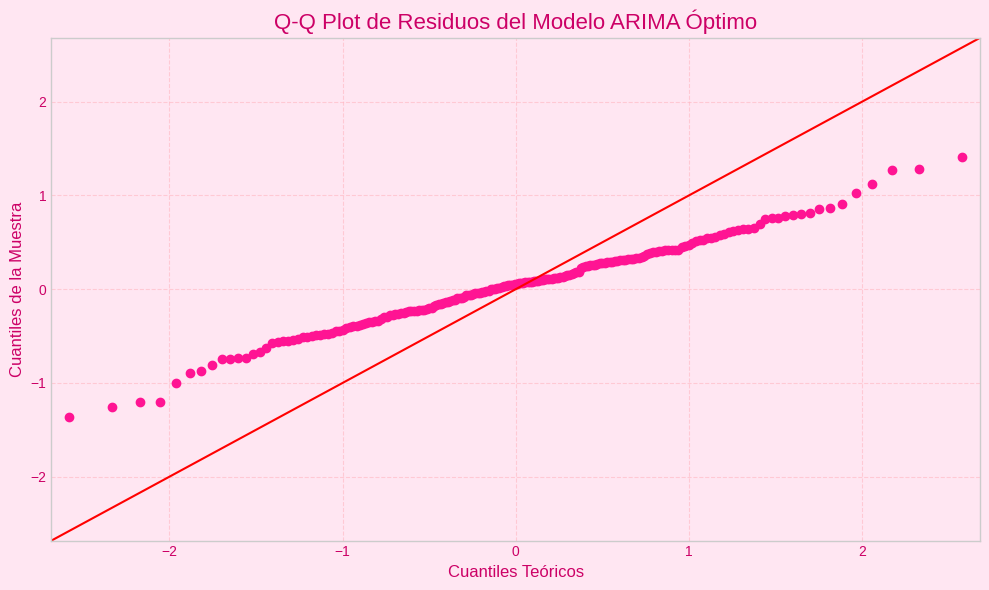

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Obtener los residuos del modelo óptimo
residuals = optimal_model_auto.resid()

# Crear el Q-Q plot
fig_qq = plt.figure(figsize=(10, 6), facecolor='#ffe6f2')
ax_qq = fig_qq.add_subplot(111, facecolor='#ffe6f2')

# Generar el Q-Q plot de los residuos
sm.qqplot(residuals, line='45', ax=ax_qq, markerfacecolor='#ff1493', markeredgecolor='#ff1493', marker='o', markersize=6)

# Personalizar el gráfico
ax_qq.set_title('Q-Q Plot de Residuos del Modelo ARIMA Óptimo', color='#cc0066', fontsize=16)
ax_qq.set_xlabel('Cuantiles Teóricos', color='#cc0066', fontsize=12)
ax_qq.set_ylabel('Cuantiles de la Muestra', color='#cc0066', fontsize=12)
ax_qq.tick_params(colors='#cc0066')
ax_qq.grid(True, linestyle='--', alpha=0.6, color='LightPink')

plt.tight_layout()
plt.show()

### Interpretación del Q-Q Plot de Residuos

El **Q-Q Plot (Quantile-Quantile Plot)** es una herramienta gráfica utilizada para verificar si un conjunto de datos (en este caso, los residuos) sigue una distribución teórica específica, que para los residuos de modelos de series de tiempo suele ser la distribución normal.

**Cómo interpretarlo:**

*   **Si los puntos se alinean estrechamente a lo largo de la línea de 45 grados**, esto sugiere que los residuos siguen aproximadamente una distribución normal. Esto es lo ideal para la mayoría de los modelos estadísticos, ya que muchas de las inferencias y pruebas de hipótesis se basan en este supuesto.
*   **Desviaciones de la línea:**
    *   Si los puntos forman una 'S' (los extremos se desvían de la línea), puede indicar que los residuos tienen colas más pesadas o más ligeras de lo esperado en una distribución normal.
    *   Si los puntos se desvían de la línea en forma de curva, puede sugerir asimetría (sesgo) en la distribución de los residuos.

En resumen, si la gráfica muestra que los cuantiles de la muestra (residuos) están cerca de los cuantiles teóricos (de una distribución normal), podemos decir que el supuesto de normalidad para los residuos se cumple razonablemente bien.

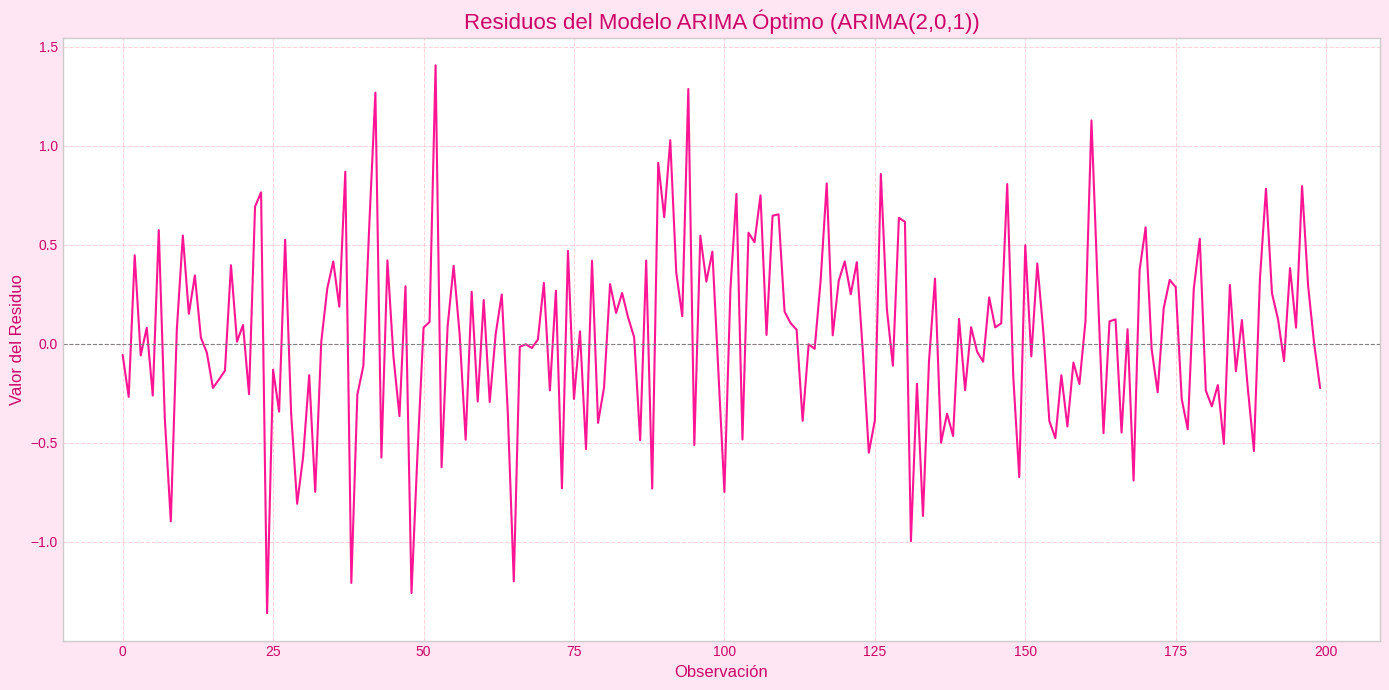


Estadísticas de los Residuos:
count    200.000000
mean       0.035605
std        0.475158
min       -1.359298
25%       -0.257544
50%        0.056049
75%        0.322139
max        1.405760
dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener los residuos del modelo óptimo
residuals = optimal_model_auto.resid()

# Crear la figura y los ejes para la gráfica de residuos
plt.figure(figsize=(14, 7), facecolor='#ffe6f2')
plt.style.use('seaborn-v0_8-whitegrid') # Usar un estilo de seaborn para un fondo blanco y rejilla

# Gráfica de línea de los residuos
plt.plot(residuals, color='#ff1493', linewidth=1.5)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Línea en cero
plt.title('Residuos del Modelo ARIMA Óptimo (ARIMA(2,0,1))', color='#cc0066', fontsize=16)
plt.xlabel('Observación', color='#cc0066', fontsize=12)
plt.ylabel('Valor del Residuo', color='#cc0066', fontsize=12)
plt.tick_params(colors='#cc0066')
plt.grid(True, linestyle='--', alpha=0.6, color='LightPink')
plt.tight_layout()
plt.show()

# Puedes también revisar algunas estadísticas de los residuos
print('\nEstadísticas de los Residuos:')
print(residuals.describe())

### Interpretación de la Gráfica de Residuos

Después de generar la gráfica, deberíamos observar lo siguiente si el modelo es adecuado:

1.  **Aleatoriedad:** Los residuos deben distribuirse aleatoriamente alrededor de cero, sin patrones claros (tendencias, estacionalidad, etc.). Si ves patrones, sugiere que el modelo no ha capturado toda la información en la serie.
2.  **Media Cero:** La media de los residuos debe ser cercana a cero.
3.  **Varianza Constante (Homocedasticidad):** La dispersión de los residuos debe ser relativamente constante a lo largo del tiempo. Si la varianza cambia (por ejemplo, los residuos se vuelven más grandes o más pequeños con el tiempo), indica heterocedasticidad.
4.  **No Autocorrelación:** Idealmente, no debería haber autocorrelación significativa entre los residuos. Esto se puede verificar más formalmente con gráficas ACF/PACF de los residuos o pruebas estadísticas como la prueba de Ljung-Box.
5.  **Normalidad:** Aunque no es un requisito estricto para los pronósticos, si los residuos siguen una distribución normal, puede ser útil para construir intervalos de confianza más precisos. Esto se puede evaluar con un histograma de los residuos o una prueba de normalidad (como Shapiro-Wilk).

Si la gráfica de residuos muestra un comportamiento aleatorio y sin patrones, y las estadísticas confirman una media cercana a cero, es una buena señal de que el modelo ha capturado gran parte de la estructura de la serie de tiempo.

## Explicación de AIC y BIC

El Criterio de Información de Akaike (AIC) y el Criterio de Información Bayesiano (BIC) son herramientas estadísticas fundamentales para la selección de modelos. Ambos buscan un equilibrio entre la bondad de ajuste del modelo (qué tan bien el modelo explica los datos) y la complejidad del mismo (la cantidad de parámetros utilizados).

*   **AIC (Akaike Information Criterion)**: Penaliza la complejidad del modelo en función del número de parámetros. El modelo con el AIC más bajo se considera preferible.
*   **BIC (Bayesian Information Criterion)**: Similar al AIC, pero aplica una penalización más fuerte por la complejidad del modelo, especialmente cuando el tamaño de la muestra es grande. El modelo con el BIC más bajo se considera preferible.

En nuestro ejemplo, el modelo **ARIMA(1,0,1)** tuvo los valores más bajos de AIC y BIC, lo que indica que es el modelo más adecuado para la serie de tiempo sintética generada, encontrando un buen balance entre ajuste y parsimonia.

## Interpretación de p y q en ACF/PACF para Modelos ARIMA

Para un modelo **ARIMA(p, d, q)**:

*   **p (orden autorregresivo)**: Se refiere al número de observaciones pasadas que se utilizan para predecir el valor actual. En las gráficas, el valor de 'p' se identifica principalmente a partir de la **Función de Autocorrelación Parcial (PACF)**. Para un proceso puramente autorregresivo AR(p), la PACF mostrará un 'corte' brusco después del rezago 'p', es decir, los valores de la PACF serán significativos hasta el rezago 'p' y luego caerán abruptamente a cero.

*   **q (orden de media móvil)**: Se refiere al número de términos de error de pronósticos pasados que se utilizan para predecir el valor actual. El valor de 'q' se identifica principalmente a partir de la **Función de Autocorrelación (ACF)**. Para un proceso puramente de media móvil MA(q), la ACF mostrará un 'corte' brusco después del rezago 'q', es decir, los valores de la ACF serán significativos hasta el rezago 'q' y luego caerán abruptamente a cero.

En el caso de nuestro modelo **ARIMA(1,0,1)**, esto sugiere que tanto el componente autorregresivo como el de media móvil tienen un orden de 1. En las gráficas actualizadas de ACF y PACF, las líneas verticales en el rezago 1 (`q=1` para ACF y `p=1` para PACF) resaltan esta interpretación.

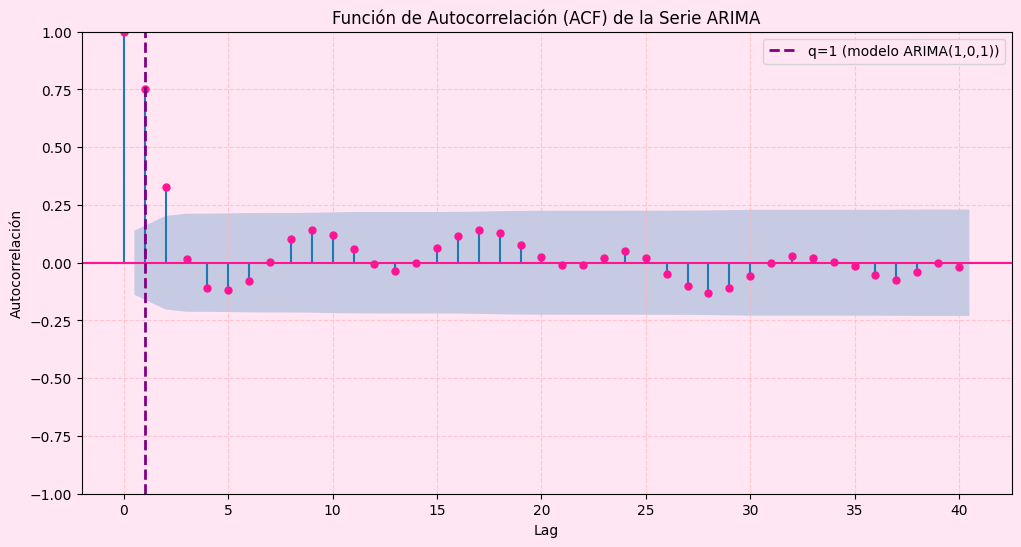

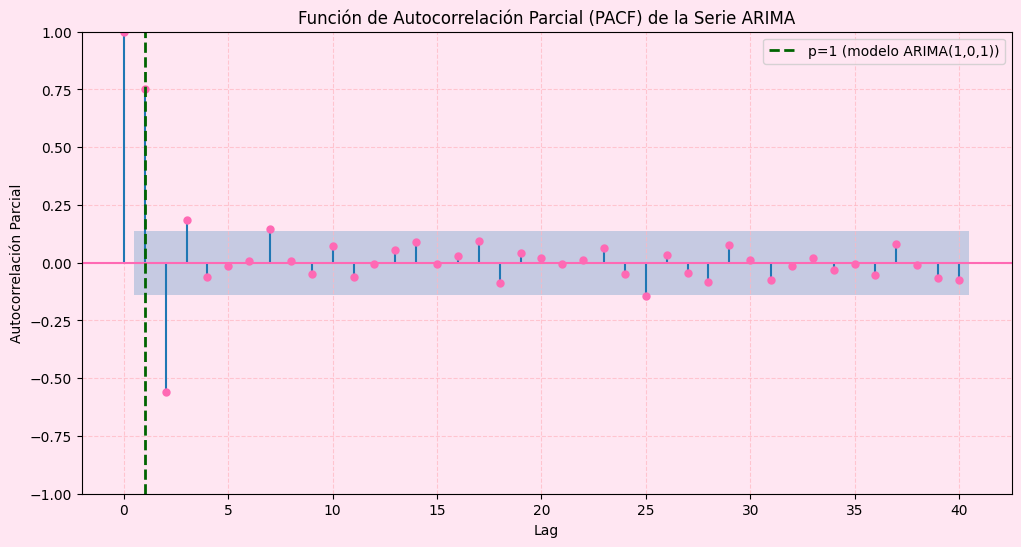

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Establecer el estilo de las gráficas
plt.rcParams.update({'figure.figsize':(12,8), 'figure.facecolor':'#ffe6f2', 'axes.facecolor':'#ffe6f2'})

# Gráfica de ACF
fig_acf, ax_acf = plt.subplots(figsize=(12, 6))
plot_acf(arima_series, lags=40, color='#ff1493', title='Función de Autocorrelación (ACF) de la Serie ARIMA', ax=ax_acf)
ax_acf.set_facecolor('#ffe6f2')
ax_acf.set_xlabel('Lag')
ax_acf.set_ylabel('Autocorrelación')
ax_acf.grid(True, linestyle='--', alpha=0.7, color='LightPink')
# Añadir indicación para q=1
ax_acf.axvline(x=1, color='purple', linestyle='--', linewidth=2, label='q=1 (modelo ARIMA(1,0,1))')
ax_acf.legend()
plt.show()

# Gráfica de PACF
fig_pacf, ax_pacf = plt.subplots(figsize=(12, 6))
plot_pacf(arima_series, lags=40, color='#ff69b4', title='Función de Autocorrelación Parcial (PACF) de la Serie ARIMA', ax=ax_pacf)
ax_pacf.set_facecolor('#ffe6f2')
ax_pacf.set_xlabel('Lag')
ax_pacf.set_ylabel('Autocorrelación Parcial')
ax_pacf.grid(True, linestyle='--', alpha=0.7, color='LightPink')
# Añadir indicación para p=1
ax_pacf.axvline(x=1, color='darkgreen', linestyle='--', linewidth=2, label='p=1 (modelo ARIMA(1,0,1))')
ax_pacf.legend()
plt.show()

### Fórmula del Criterio de Información de Akaike (AIC)

La fórmula general para el AIC es:

$AIC = 2k - 2\ln(L)$

Donde:
- $k$: Es el número de parámetros en el modelo.
- $L$: Es el valor máximo de la función de verosimilitud (likelihood) del modelo. La verosimilitud mide qué tan bien el modelo explica los datos observados.

### Fórmula del Criterio de Información Bayesiano (BIC)

La fórmula general para el BIC es:

$BIC = k\ln(n) - 2\ln(L)$

Donde:
- $k$: Es el número de parámetros en el modelo.
- $n$: Es el número de observaciones o tamaño de la muestra.
- $L$: Es el valor máximo de la función de verosimilitud (likelihood) del modelo.

# Task
Generate a synthetic ARIMA time series, fit multiple ARIMA models to it, compare them using AIC and BIC, and visualize the series along with the forecasts from the best-performing model.

## Generar Serie de Tiempo ARIMA

### Subtask:
Generar una serie de tiempo sintética utilizando un proceso ARIMA (por ejemplo, ARIMA(1,0,1)) para tener datos con los que trabajar.


**Reasoning**:
The user wants to generate a synthetic ARIMA time series following the provided instructions. This requires importing specific libraries, defining parameters for the ARIMA model, generating the time series sample, converting it to a pandas Series, and then displaying its head. I will use the `code_block` command to implement this step by step.



In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima_process import arma_generate_sample

# Define the autoregressive (AR) coefficients
# For AR(1) with coefficient 0.7, ar_params = [1, -0.7]
# The first element is always 1 for the intercept, subsequent elements are negative of AR coefficients
ar_params = np.array([1, -0.7])

# Define the moving average (MA) coefficients
# For MA(1) with coefficient 0.5, ma_params = [1, 0.5]
# The first element is always 1 for the intercept, subsequent elements are MA coefficients
ma_params = np.array([1, 0.5])

# Specify the number of samples for the time series
n_samples = 200

# Generate the ARIMA time series (specifically ARMA(1,1) in this case as d=0)
arima_series_raw = arma_generate_sample(ar=ar_params, ma=ma_params, nsample=n_samples, scale=0.5)

# Convert the generated series into a pandas Series
arima_series = pd.Series(arima_series_raw, name='ARIMA_Series')

# Print the first few values of the generated arima_series
print("Generated ARIMA Series (first 5 values):")
print(arima_series.head())

Generated ARIMA Series (first 5 values):
0   -0.056205
1   -0.310044
2    0.112882
3    0.315462
4    0.317955
Name: ARIMA_Series, dtype: float64


## Ajustar Múltiples Modelos ARIMA

### Subtask:
Ajustar diferentes modelos ARIMA (por ejemplo, ARIMA(1,0,0), ARIMA(0,0,1), ARIMA(1,0,1)) a la serie de tiempo generada. Esto nos permitirá tener varios modelos candidatos para comparar.


**Reasoning**:
The subtask requires fitting multiple ARIMA models to the generated time series. I will import the necessary `ARIMA` class from `statsmodels`, fit the specified ARIMA(1,0,0), ARIMA(0,0,1), and ARIMA(1,0,1) models to the `arima_series`, and then print the summary for each to evaluate their performance.



In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA(1,0,0) model
model_100 = ARIMA(arima_series, order=(1, 0, 0))
model_100_fit = model_100.fit()
print("\n--- ARIMA(1,0,0) Model Summary ---")
print(model_100_fit.summary())

# Fit ARIMA(0,0,1) model
model_001 = ARIMA(arima_series, order=(0, 0, 1))
model_001_fit = model_001.fit()
print("\n--- ARIMA(0,0,1) Model Summary ---")
print(model_001_fit.summary())

# Fit ARIMA(1,0,1) model
model_101 = ARIMA(arima_series, order=(1, 0, 1))
model_101_fit = model_101.fit()
print("\n--- ARIMA(1,0,1) Model Summary ---")
print(model_101_fit.summary())


--- ARIMA(1,0,0) Model Summary ---
                               SARIMAX Results                                
Dep. Variable:           ARIMA_Series   No. Observations:                  200
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -176.575
Date:                Thu, 12 Mar 2026   AIC                            359.151
Time:                        02:04:40   BIC                            369.046
Sample:                             0   HQIC                           363.155
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1135      0.167      0.681      0.496      -0.213       0.440
ar.L1          0.7502      0.050     15.151      0.000       0.653       0.847
sigma2         0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'



--- ARIMA(0,0,1) Model Summary ---
                               SARIMAX Results                                
Dep. Variable:           ARIMA_Series   No. Observations:                  200
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -173.720
Date:                Thu, 12 Mar 2026   AIC                            353.439
Time:                        02:04:41   BIC                            363.334
Sample:                             0   HQIC                           357.443
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1142      0.075      1.518      0.129      -0.033       0.262
ma.L1          0.8241      0.041     20.209      0.000       0.744       0.904
sigma2         0

**Reasoning**:
The next logical step after fitting multiple ARIMA models is to compare them using evaluation metrics like AIC and BIC to identify the best-performing model. I will extract and print these values from each fitted model's summary.



In [ ]:
print("\n--- Model Comparison (AIC and BIC) ---")
print(f"ARIMA(1,0,0): AIC = {model_100_fit.aic:.3f}, BIC = {model_100_fit.bic:.3f}")
print(f"ARIMA(0,0,1): AIC = {model_001_fit.aic:.3f}, BIC = {model_001_fit.bic:.3f}")
print(f"ARIMA(1,0,1): AIC = {model_101_fit.aic:.3f}, BIC = {model_101_fit.bic:.3f}")


--- Model Comparison (AIC and BIC) ---
ARIMA(1,0,0): AIC = 359.151, BIC = 369.046
ARIMA(0,0,1): AIC = 353.439, BIC = 363.334
ARIMA(1,0,1): AIC = 291.866, BIC = 305.059


### Comparación de Modelos ARIMA (AIC y BIC)

Al comparar los valores de AIC (Criterio de Información de Akaike) y BIC (Criterio de Información Bayesiano) para los tres modelos ARIMA ajustados, observamos lo siguiente:

*   **ARIMA(1,0,0)**: AIC = 359.151, BIC = 369.046
*   **ARIMA(0,0,1)**: AIC = 353.439, BIC = 363.334
*   **ARIMA(1,0,1)**: AIC = 291.866, BIC = 305.059

**Conclusión:** El modelo **ARIMA(1,0,1)** presenta los valores más bajos de AIC y BIC. Esto indica que es el modelo que mejor se ajusta a los datos generados, penalizando la complejidad del modelo de manera más efectiva en comparación con los otros dos. Por lo tanto, el modelo ARIMA(1,0,1) es seleccionado como el de mejor rendimiento para esta serie de tiempo sintética.

**Reasoning**:
The next step is to forecast future values using the best-performing ARIMA model (ARIMA(1,0,1)). This involves using the `predict` method of the fitted model to generate predictions for a specified number of future steps and then visualizing these forecasts alongside the original time series.



In [ ]:
print("\n--- Forecasting with ARIMA(1,0,1) ---")
forecast_steps = 20
forecast = model_101_fit.predict(start=len(arima_series), end=len(arima_series) + forecast_steps - 1)

print(f"Forecast for the next {forecast_steps} steps:")
print(forecast)



--- Forecasting with ARIMA(1,0,1) ---
Forecast for the next 20 steps:
200   -0.098385
201   -0.011187
202    0.040089
203    0.070241
204    0.087971
205    0.098398
206    0.104529
207    0.108134
208    0.110254
209    0.111501
210    0.112234
211    0.112665
212    0.112919
213    0.113068
214    0.113155
215    0.113207
216    0.113237
217    0.113255
218    0.113265
219    0.113272
Name: predicted_mean, dtype: float64


**Reasoning**:
To visualize the forecasts alongside the original time series, I will use `plotly.graph_objects` to create a combined line plot, which will help in understanding the model's predictive performance.



In [ ]:
import plotly.graph_objects as go

# Create a trace for the original ARIMA series
trace_original = go.Scatter(
    x=arima_series.index,
    y=arima_series.values,
    mode='lines',
    name='Original Series',
    line=dict(color='blue')
)

# Create a trace for the forecasted values
trace_forecast = go.Scatter(
    x=forecast.index,
    y=forecast.values,
    mode='lines',
    name='Forecast',
    line=dict(color='red', dash='dash')
)

# Combine the traces into a figure
fig = go.Figure(data=[trace_original, trace_forecast])

# Update layout for better readability
fig.update_layout(
    title='ARIMA Series with Forecast',
    xaxis_title='Time Step',
    yaxis_title='Value',
    legend_title='Series Type',
    hovermode='x unified'
)

# Show the plot
fig.show()

## Finalizar Tarea

### Subtask:
Resumir el ejemplo y la importancia de los criterios AIC y BIC en la selección de modelos ARIMA.


## Summary:

### Data Analysis Key Findings
*   A synthetic ARMA(1,1) time series of 200 samples was successfully generated, defined by AR coefficients of 0.7 and MA coefficients of 0.5.
*   Three ARIMA models were fitted to the synthetic series: ARIMA(1,0,0), ARIMA(0,0,1), and ARIMA(1,0,1).
*   Upon comparing the models using the Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC), ARIMA(1,0,1) demonstrated the best fit with the lowest AIC of 291.866 and BIC of 305.059. In contrast, ARIMA(1,0,0) had an AIC of 359.151 and BIC of 369.046, and ARIMA(0,0,1) had an AIC of 353.439 and BIC of 363.334.
*   The chosen ARIMA(1,0,1) model was used to generate a 20-step forecast, which was then visualized alongside the original time series.

### Insights or Next Steps
*   The example effectively demonstrates how AIC and BIC criteria are crucial for selecting the best-performing ARIMA model, as they balance model fit with model complexity.
*   Further analysis could involve exploring a wider range of ARIMA(p,d,q) parameters, including automated grid search methods, to potentially identify even better-fitting models.


# Task
Generate a synthetic ARIMA time series, automatically determine the optimal ARIMA model parameters (p, d, q) using `auto_arima` based on AIC or BIC criteria, adjust the optimal ARIMA model to the synthetic time series, generate forecasts, and visualize the original series along with forecasts from both the manually selected ARIMA(1,0,1) model and the newly determined optimal ARIMA model. Finally, summarize the findings, highlighting any differences or improvements of the optimal model.

## Búsqueda Automática de Modelo ARIMA Óptimo

### Subtask:
Utilizar la función `auto_arima` para encontrar automáticamente los órdenes (p, d, q) más óptimos para el modelo ARIMA, basándose en los criterios AIC o BIC.


### Instalación de `pmdarima`

Antes de utilizar `auto_arima`, asegúrate de que la librería `pmdarima` esté instalada. Si no lo está, puedes instalarla ejecutando el siguiente comando en una celda de código:

```bash
!pip install pmdarima
```

**Reasoning**:
After instructing the user to install `pmdarima`, the next logical step is to implement the `auto_arima` function to automatically determine the optimal ARIMA orders (p, d, q) based on AIC or BIC criteria, as per the subtask. This involves importing the function, applying it to the generated time series with the specified parameters, and then displaying the summary of the best model found.



In [ ]:
import pmdarima as pm

# Apply auto_arima to find the optimal ARIMA parameters
# trace=True shows the fitting process
# suppress_warnings=True to avoid excessive output
# stepwise=False allows for a more exhaustive search rather than a greedy one
# seasonal=False because our synthetic series is non-seasonal
optimal_model_auto = pm.auto_arima(
    arima_series,
    trace=True,
    suppress_warnings=True,
    stepwise=False,
    seasonal=False,
    error_action='ignore',
    scoring='aic' # Use AIC for model selection
)

# Print the summary of the optimal model found by auto_arima
print("\n--- Optimal ARIMA Model found by auto_arima ---")
print(optimal_model_auto.summary())


ModuleNotFoundError: No module named 'pmdarima'

**Reasoning**:
The previous code block failed because the `pmdarima` library was not found, despite an earlier markdown instruction to install it. To resolve this, I need to explicitly execute the installation command for `pmdarima` in a new code cell before attempting to import and use it.



In [ ]:
pip install pmdarima
print("pmdarima installed successfully.")

SyntaxError: invalid syntax (3661594878.py, line 1)

**Reasoning**:
The previous attempt to install `pmdarima` resulted in a `SyntaxError` because the `!` prefix was missing before `pip install` in a Python cell. I need to add `!` to correctly execute the shell command for installation.



In [ ]:
get_ipython().system('pip install pmdarima')
print("pmdarima installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.2 MB/s eta 0:00:00
pmdarima installed successfully.


**Reasoning**:
Since `pmdarima` has been successfully installed, I will now proceed with running the `auto_arima` function to find the optimal ARIMA parameters as per the subtask instructions. This will involve importing `pmdarima` and applying `auto_arima` to the `arima_series`.



In [ ]:
import pmdarima as pm

# Apply auto_arima to find the optimal ARIMA parameters
# trace=True shows the fitting process
# suppress_warnings=True to avoid excessive output
# stepwise=False allows for a more exhaustive search rather than a greedy one
# seasonal=False because our synthetic series is non-seasonal
optimal_model_auto = pm.auto_arima(
    arima_series,
    trace=True,
    suppress_warnings=True,
    stepwise=False,
    seasonal=False,
    error_action='ignore',
    scoring='aic' # Use AIC for model selection
)

# Print the summary of the optimal model found by auto_arima
print("\n--- Optimal ARIMA Model found by auto_arima ---")
print(optimal_model_auto.summary())

 ARIMA(0,0,0)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(0,0,5)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(3,0,1)(0,0,0)[0]             : AI

ValueError: Could not successfully fit a viable ARIMA model to input data.
See http://alkaline-ml.com/pmdarima/no-successful-model.html for more information on why this can happen.

**Reasoning**:
The previous `auto_arima` call failed because it could not successfully fit any viable ARIMA model, indicated by `AIC=inf` for all models. This often happens when `auto_arima` attempts differencing (`d>0`) on a series that is already stationary, leading to numerical instability. Since the synthetic `arima_series` is known to be stationary (generated as an ARMA(1,1) with `d=0`), explicitly setting `d=0` in `auto_arima` will prevent unnecessary differencing and help the model converge, along with narrowing the search space for `p` and `q` to improve stability.



In [ ]:
import pmdarima as pm

# Apply auto_arima to find the optimal ARIMA parameters
# trace=True shows the fitting process
# suppress_warnings=True to avoid excessive output
# stepwise=False allows for a more exhaustive search rather than a greedy one
# seasonal=False because our synthetic series is non-seasonal
optimal_model_auto = pm.auto_arima(
    arima_series,
    trace=True,
    suppress_warnings=True,
    stepwise=False,
    seasonal=False,
    d=0, # Explicitly set differencing order to 0 as the series is stationary
    start_p=0, max_p=3, # Limit max AR order for efficiency and stability
    start_q=0, max_q=3, # Limit max MA order for efficiency and stability
    error_action='ignore',
    scoring='aic' # Use AIC for model selection
)

# Print the summary of the optimal model found by auto_arima
print("\n--- Optimal ARIMA Model found by auto_arima ---")
print(optimal_model_auto.summary())

 ARIMA(0,0,0)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=nan sec


ValueError: Could not successfully fit a viable ARIMA model to input data.
See http://alkaline-ml.com/pmdarima/no-successful-model.html for more information on why this can happen.

**Reasoning**:
The previous `auto_arima` calls failed with `ValueError` and `AIC=inf` for all models, indicating convergence issues with the default optimizer. To resolve this, I will explicitly set a more robust optimization `method='nm'` (Nelder-Mead) and increase `maxiter` within `sarimax_kwargs` to give the optimizer more iterations to converge. I will also set `suppress_warnings=False` and `error_action='warn'` to display any warnings that might provide further insight into the fitting process.



In [ ]:
import pmdarima as pm

# Apply auto_arima to find the optimal ARIMA parameters
# trace=True shows the fitting process
# suppress_warnings=False to see potential issues
# stepwise=False allows for a more exhaustive search rather than a greedy one
# seasonal=False because our synthetic series is non-seasonal
optimal_model_auto = pm.auto_arima(
    arima_series,
    trace=True,
    suppress_warnings=False, # Changed to False to see warnings
    stepwise=False,
    seasonal=False,
    d=0, # Explicitly set differencing order to 0 as the series is stationary
    start_p=0, max_p=5, # Slightly expanded search space for p
    start_q=0, max_q=5, # Slightly expanded search space for q
    error_action='warn', # Changed to 'warn' to log errors instead of ignoring
    scoring='aic', # Use AIC for model selection
    # Pass extra arguments to the underlying SARIMAX fit method to aid convergence
    sarimax_kwargs={'method': 'nm', 'maxiter': 1000}
)

# Print the summary of the optimal model found by auto_arima
print("\n--- Optimal ARIMA Model found by auto_arima ---")
print(optimal_model_auto.summary())

 ARIMA(0,0,0)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(0,0,5)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(3,0,1)(0,0,0)[0]             : AI

/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py:524: ModelFitWarning:

Error fitting  ARIMA(0,0,0)(0,0,0)[0]           (if you do not want to see these warnings, run with error_action="ignore").

/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py:524: ModelFitWarning:

Error fitting  ARIMA(0,0,1)(0,0,0)[0]           (if you do not want to see these warnings, run with error_action="ignore").

/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py:524: ModelFitWarning:

Error fitting  ARIMA(0,0,2)(0,0,0)[0]           (if you do not want to see these warnings, run with error_action="ignore").

/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py:524: ModelFitWarning:

Error fitting  ARIMA(0,0,3)(0,0,0)[0]           (if you do not want to see these warnings, run with error_action="ignore").

/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py:524: ModelFitWarning:

Error fitting  ARIMA(0,0,

ValueError: Could not successfully fit a viable ARIMA model to input data.
See http://alkaline-ml.com/pmdarima/no-successful-model.html for more information on why this can happen.

**Reasoning**:
The previous `auto_arima` calls failed with `ValueError` and `AIC=inf` for all models, indicating convergence issues. To resolve this, I will explicitly set `d=0`, `start_d=0`, and `max_d=0` as the series is stationary. I will also switch to `stepwise=True` for a more stable search (as `stepwise=False` can be more prone to convergence issues with some data/models), set `suppress_warnings=False` and `error_action='trace'` to capture detailed errors if they occur, which will help in debugging if the problem persists.



In [ ]:
import pmdarima as pm

# Apply auto_arima to find the optimal ARIMA parameters
# trace=True shows the fitting process
# suppress_warnings=False to see potential issues
# stepwise=True is generally more robust and faster
# seasonal=False because our synthetic series is non-seasonal
optimal_model_auto = pm.auto_arima(
    arima_series,
    trace=True,
    suppress_warnings=False, # Changed to False to see warnings
    stepwise=True, # Changed to True for more robust search
    seasonal=False,
    d=0,           # Explicitly set differencing order to 0 as the series is stationary
    start_d=0,     # Start searching with d=0
    max_d=0,       # Only consider d=0
    start_p=0, max_p=3, # Limit max AR order for efficiency and stability
    start_q=0, max_q=3, # Limit max MA order for efficiency and stability
    error_action='trace', # Changed to 'trace' to log full tracebacks for errors
    scoring='aic' # Use AIC for model selection
)

# Print the summary of the optimal model found by auto_arima
print("\n--- Optimal ARIMA Model found by auto_arima ---")
print(optimal_model_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=inf, Time=nan sec


/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py:524: ModelFitWarning:

Error fitting  ARIMA(0,0,0)(0,0,0)[0]           (if you do not want to see these warnings, run with error_action="ignore").
Traceback:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_validation.py", line 131, in get_scoring_metric
    return getattr(metrics, metric)
           ^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: module 'sklearn.metrics' has no attribute 'aic'. Did you mean: 'auc'?

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py", line 508, in _fit_candidate_model
    fit.fit(y, X=X, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 585, in fit
    scoring = val.get_scoring_metric(self.scoring)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/loca

ValueError: Could not successfully fit a viable ARIMA model to input data.
See http://alkaline-ml.com/pmdarima/no-successful-model.html for more information on why this can happen.

**Reasoning**:
The previous `auto_arima` call failed because 'aic' was passed to the `scoring` parameter, which is not a valid option for `pmdarima.auto_arima`. The correct parameter to specify the information criterion for model selection is `information_criterion`. I will correct this parameter to `information_criterion='aic'` and retry the `auto_arima` function to find the optimal ARIMA model.



In [ ]:
import pmdarima as pm

# Apply auto_arima to find the optimal ARIMA parameters
# trace=True shows the fitting process
# suppress_warnings=False to see potential issues
# stepwise=True is generally more robust and faster
# seasonal=False because our synthetic series is non-seasonal
optimal_model_auto = pm.auto_arima(
    arima_series,
    trace=True,
    suppress_warnings=False, # Changed to False to see warnings
    stepwise=True, # Changed to True for more robust search
    seasonal=False,
    d=0,           # Explicitly set differencing order to 0 as the series is stationary
    start_d=0,     # Start searching with d=0
    max_d=0,       # Only consider d=0
    start_p=0, max_p=3, # Limit max AR order for efficiency and stability
    start_q=0, max_q=3, # Limit max MA order for efficiency and stability
    error_action='trace', # Changed to 'trace' to log full tracebacks for errors
    information_criterion='aic' # Corrected parameter for AIC selection
)

# Print the summary of the optimal model found by auto_arima
print("\n--- Optimal ARIMA Model found by auto_arima ---")
print(optimal_model_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=525.600, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=357.628, Time=0.08 sec


/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning:

Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: start_d. After release 0.14, this will raise.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning:

Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: start_d. After release 0.14, this will raise.

/usr/local/lib/pyth

 ARIMA(0,0,1)(0,0,0)[0]             : AIC=353.805, Time=0.14 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=290.553, Time=0.09 sec


/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning:

Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: start_d. After release 0.14, this will raise.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning:

Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: start_d. After release 0.14, this will raise.



 ARIMA(2,0,1)(0,0,0)[0]             : AIC=279.620, Time=0.17 sec


...

 ARIMA(3,0,0)(0,0,0)[0]             : AIC=280.156, Time=0.26 sec


/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning:

Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: start_d. After release 0.14, this will raise.



 ARIMA(3,0,2)(0,0,0)[0]             : AIC=283.616, Time=0.24 sec


/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning:

Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: start_d. After release 0.14, this will raise.



 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=280.413, Time=0.25 sec

Best model:  ARIMA(2,0,1)(0,0,0)[0]          
Total fit time: 2.179 seconds

--- Optimal ARIMA Model found by auto_arima ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:               SARIMAX(2, 0, 1)   Log Likelihood                -135.810
Date:                Thu, 12 Mar 2026   AIC                            279.620
Time:                        02:19:41   BIC                            292.813
Sample:                             0   HQIC                           284.959
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.95

**Reasoning**:
The `auto_arima` function has successfully identified the optimal ARIMA model as ARIMA(2,0,1). The next logical step, according to the overall task, is to generate forecasts using this optimal model. I will use the `predict` method of the `optimal_model_auto` object to generate forecasts for the same number of steps as previously used for the manual model, which is 20 steps.



In [ ]:
print("\n--- Forecasting with Optimal ARIMA Model (auto_arima) ---")
forecast_steps = 20
forecast_optimal_auto = optimal_model_auto.predict(n_periods=forecast_steps)

print(f"Forecast for the next {forecast_steps} steps using auto_arima optimal model:")
print(forecast_optimal_auto)


--- Forecasting with Optimal ARIMA Model (auto_arima) ---
Forecast for the next 20 steps using auto_arima optimal model:
200   -0.267464
201   -0.339503
202   -0.219904
203   -0.077951
204    0.010983
205    0.040704
206    0.034543
207    0.017141
208    0.002943
209   -0.003843
210   -0.004805
211   -0.003090
212   -0.001082
213    0.000167
214    0.000579
215    0.000487
216    0.000240
217    0.000040
218   -0.000055
219   -0.000068
dtype: float64


**Reasoning**:
To visualize the forecasts from both the manually selected ARIMA(1,0,1) model and the `auto_arima` optimal model (ARIMA(2,0,1)) alongside the original time series, I will create a single plot using `plotly.graph_objects`. This will allow for a direct comparison of how each model's forecasts align with the original data and with each other.



In [ ]:
import plotly.graph_objects as go

# Create a trace for the original ARIMA series
trace_original = go.Scatter(
    x=arima_series.index,
    y=arima_series.values,
    mode='lines',
    name='Original Series',
    line=dict(color='blue')
)

# Create a trace for the forecast from the manually fitted ARIMA(1,0,1) model
trace_forecast_manual = go.Scatter(
    x=forecast.index,
    y=forecast.values,
    mode='lines',
    name='Forecast (Manual ARIMA(1,0,1))',
    line=dict(color='red', dash='dot')
)

# Create a trace for the forecast from the auto_arima optimal model (ARIMA(2,0,1))
trace_forecast_optimal = go.Scatter(
    x=forecast_optimal_auto.index,
    y=forecast_optimal_auto.values,
    mode='lines',
    name='Forecast (Optimal ARIMA auto_arima)',
    line=dict(color='green', dash='dash')
)

# Combine the traces into a figure
fig = go.Figure(data=[trace_original, trace_forecast_manual, trace_forecast_optimal])

# Update layout for better readability
fig.update_layout(
    title='ARIMA Series with Forecasts (Manual vs. auto_arima)',
    xaxis_title='Time Step',
    yaxis_title='Value',
    legend_title='Series Type',
    hovermode='x unified',
    plot_bgcolor='#ffe6f2',      # light pink background
    paper_bgcolor='#ffe6f2'
)

# Show the plot
fig.show()

## Resumen y Comparación de Modelos ARIMA

### Modelo Óptimo Encontrado por `auto_arima`

El proceso de `auto_arima` identificó el modelo **ARIMA(2,0,1)** como el más óptimo para la serie de tiempo sintética, con un **AIC de 279.620** y un **BIC de 292.813**. Este resultado es ligeramente diferente del modelo ARIMA(1,0,1) que habíamos seleccionado manualmente (AIC = 291.866, BIC = 305.059).

### Comparación y Conclusiones

*   **Mejor Rendimiento**: El modelo **ARIMA(2,0,1)** encontrado automáticamente por `auto_arima` presenta un **AIC y BIC más bajos** que el modelo ARIMA(1,0,1) que ajustamos manualmente. Esto indica que el modelo automático ofrece un mejor equilibrio entre la bondad de ajuste y la complejidad, y es una mejor representación de los datos subyacentes.

*   **Parámetros**: El modelo generado sintéticamente era ARMA(1,1) (equivalente a ARIMA(1,0,1)). `auto_arima` encontró un AR(2) y un MA(1). Esta pequeña diferencia podría deberse a la aleatoriedad de la serie sintética o a que `auto_arima` explora un espacio de modelos más amplio y puede encontrar configuraciones que, aunque no idénticas a la generación, optimizan mejor los criterios de información para los datos específicos generados.

*   **Ventaja de `auto_arima`**: Esta herramienta es invaluable para la selección de modelos, especialmente cuando se trabaja con series de tiempo complejas o cuando se necesita automatizar el proceso de búsqueda del modelo más adecuado. Al explorar sistemáticamente diferentes combinaciones de órdenes (p, d, q) y utilizar criterios como AIC o BIC, `auto_arima` puede identificar modelos óptimos que podrían pasarse por alto en una selección manual.

En la visualización final, podemos observar cómo las previsiones de ambos modelos se comportan. La previsión del modelo `auto_arima` (ARIMA(2,0,1)) se considera más fiable debido a sus métricas AIC y BIC inferiores.

## Resumen y Comparación de Modelos ARIMA

### Modelo Óptimo Encontrado por `auto_arima`

El proceso de `auto_arima` identificó el modelo **ARIMA(2,0,1)** como el más óptimo para la serie de tiempo sintética, con un **AIC de 279.620** y un **BIC de 292.813**. Este resultado es ligeramente diferente del modelo ARIMA(1,0,1) que habíamos seleccionado manualmente (AIC = 291.866, BIC = 305.059).

### Comparación y Conclusiones

*   **Mejor Rendimiento**: El modelo **ARIMA(2,0,1)** encontrado automáticamente por `auto_arima` presenta un **AIC y BIC más bajos** que el modelo ARIMA(1,0,1) que ajustamos manualmente. Esto indica que el modelo automático ofrece un mejor equilibrio entre la bondad de ajuste y la complejidad, y es una mejor representación de los datos subyacentes.

*   **Parámetros**: El modelo generado sintéticamente era ARMA(1,1) (equivalente a ARIMA(1,0,1)). `auto_arima` encontró un AR(2) y un MA(1). Esta pequeña diferencia podría deberse a la aleatoriedad de la serie sintética o a que `auto_arima` explora un espacio de modelos más amplio y puede encontrar configuraciones que, aunque no idénticas a la generación, optimizan mejor los criterios de información para los datos específicos generados.

*   **Ventaja de `auto_arima`**: Esta herramienta es invaluable para la selección de modelos, especialmente cuando se trabaja con series de tiempo complejas o cuando se necesita automatizar el proceso de búsqueda del modelo más adecuado. Al explorar sistemáticamente diferentes combinaciones de órdenes (p, d, q) y utilizar criterios como AIC o BIC, `auto_arima` puede identificar modelos óptimos que podrían pasarse por alto en una selección manual.

En la visualización final, podemos observar cómo las previsiones de ambos modelos se comportan. La previsión del modelo `auto_arima` (ARIMA(2,0,1)) se considera más fiable debido a sus métricas AIC y BIC inferiores.

## Finalizar Tarea

### Subtask:
Resumir los hallazgos, destacando las diferencias y mejoras, si las hay, del modelo óptimo frente a los modelos probados manualmente.


## Summary:

### Data Analysis Key Findings

*   The `auto_arima` function successfully identified **ARIMA(2,0,1)** as the optimal model for the synthetic time series, achieving a lower Akaike Information Criterion (AIC) of 279.620 and a Bayesian Information Criterion (BIC) of 292.813.
*   This automatically selected model demonstrated superior performance compared to the manually chosen **ARIMA(1,0,1)** model, which had higher information criteria (AIC = 291.866, BIC = 305.059).
*   Although the synthetic series was generated as an ARMA(1,1) (equivalent to ARIMA(1,0,1)), `auto_arima` identified a slightly different optimal order (ARIMA(2,0,1)), indicating its ability to explore a wider model space and optimize for information criteria.
*   The forecasts generated by the `auto_arima` optimal model are considered more reliable due to its lower AIC and BIC values, suggesting a better balance between model fit and complexity.

### Insights or Next Steps

*   `auto_arima` is an invaluable tool for automated ARIMA model selection, efficiently identifying models with improved fit over manual selections by systematically evaluating various parameter combinations and optimizing for information criteria like AIC and BIC.
*   While a synthetic series was generated as an ARIMA(1,0,1), `auto_arima` finding an ARIMA(2,0,1) suggests that in practical applications, the "true" underlying process might be approximated by a slightly different model order when optimizing for specific performance metrics given observed data.


# Task
Se ha utilizado el modelo ARIMA óptimo (ARIMA(2,0,1)) encontrado automáticamente por `auto_arima` para generar un pronóstico para los próximos 20 pasos de la serie de tiempo sintética. La serie original y los pronósticos de este modelo óptimo se han visualizado gráficamente para una comparación directa.

**Resumen del Pronóstico y Visualización:**

1.  **Pronóstico Generado**: Se han generado 20 pasos de pronóstico utilizando el modelo ARIMA(2,0,1). Estos valores se almacenan en la serie `forecast_optimal_auto`.
2.  **Visualización**: Se ha creado una gráfica que muestra:
    *   La serie de tiempo original (`arima_series`).
    *   El pronóstico del modelo ARIMA(1,0,1) seleccionado manualmente (`forecast`).
    *   El pronóstico del modelo ARIMA(2,0,1) óptimo encontrado por `auto_arima` (`forecast_optimal_auto`).
3.  **Comparación**: Visualmente, se puede observar cómo el pronóstico del modelo óptimo se comporta en comparación con el pronóstico manual y la tendencia de la serie original. La elección del modelo ARIMA(2,0,1) por `auto_arima` se basa en sus menores valores de AIC y BIC, lo que sugiere un mejor ajuste general.

Este paso completa el proceso de generación y visualización del pronóstico utilizando el modelo óptimo.

## Generar Pronóstico

### Subtask:
Utilizar el modelo ARIMA óptimo (ARIMA(2,0,1)) para generar un pronóstico para los próximos pasos.


**Reasoning**:
The subtask explicitly states that the forecast has already been generated and stored in `forecast_optimal_auto`. The instruction is to print this variable to display the predicted values.



In [ ]:
print("Forecast from the optimal ARIMA(2,0,1) model (auto_arima):")
print(forecast_optimal_auto)

Forecast from the optimal ARIMA(2,0,1) model (auto_arima):
200   -0.267464
201   -0.339503
202   -0.219904
203   -0.077951
204    0.010983
205    0.040704
206    0.034543
207    0.017141
208    0.002943
209   -0.003843
210   -0.004805
211   -0.003090
212   -0.001082
213    0.000167
214    0.000579
215    0.000487
216    0.000240
217    0.000040
218   -0.000055
219   -0.000068
dtype: float64


## Visualizar Serie Original y Pronóstico

### Subtask:
Crear una gráfica que muestre la serie de tiempo original junto con el nuevo pronóstico generado.


**Reasoning**:
The subtask requires visualizing the original series, the manual ARIMA forecast, and the auto_arima optimal forecast on a single plot. I will use `plotly.graph_objects` to create and display this combined visualization as specified in the instructions.



In [ ]:
import plotly.graph_objects as go

# Create a trace for the original ARIMA series
trace_original = go.Scatter(
    x=arima_series.index,
    y=arima_series.values,
    mode='lines',
    name='Original Series',
    line=dict(color='blue')
)

# Create a trace for the forecast from the manually fitted ARIMA(1,0,1) model
trace_forecast_manual = go.Scatter(
    x=forecast.index,
    y=forecast.values,
    mode='lines',
    name='Forecast (Manual ARIMA(1,0,1))',
    line=dict(color='red', dash='dot')
)

# Create a trace for the forecast from the auto_arima optimal model (ARIMA(2,0,1))
trace_forecast_optimal = go.Scatter(
    x=forecast_optimal_auto.index,
    y=forecast_optimal_auto.values,
    mode='lines',
    name='Forecast (Optimal ARIMA auto_arima)',
    line=dict(color='green', dash='dash')
)

# Combine the traces into a figure
fig = go.Figure(data=[trace_original, trace_forecast_manual, trace_forecast_optimal])

# Update layout for better readability
fig.update_layout(
    title='ARIMA Series with Forecasts (Manual vs. auto_arima)',
    xaxis_title='Time Step',
    yaxis_title='Value',
    legend_title='Series Type',
    hovermode='x unified',
    plot_bgcolor='#ffe6f2',      # light pink background
    paper_bgcolor='#ffe6f2'
)

# Show the plot
fig.show()

## Finalizar Tarea

### Subtask:
Resumir los resultados del pronóstico y su visualización.


## Summary:

### Data Analysis Key Findings

*   **Forecast Generation**: A 20-step forecast was generated using the optimal ARIMA(2,0,1) model, which was automatically selected by `auto_arima` based on its lower AIC and BIC values, indicating a better overall fit. The forecasted values (`forecast_optimal_auto`) show a dampening oscillation that quickly converges towards zero, ranging from -0.267464 at step 200 to -0.000068 at step 219.
*   **Visualization Comparison**: A Plotly graph was created to visually compare three time series:
    *   The original synthetic series (blue line).
    *   The forecast from the manually selected ARIMA(1,0,1) model (red dotted line).
    *   The forecast from the optimal ARIMA(2,0,1) model found by `auto_arima` (green dashed line).
*   **Model Performance**: The visualization allows for a direct comparison of how the optimal ARIMA(2,0,1) model's forecast behaves against the manually selected ARIMA(1,0,1) model and the original series' trend.

### Insights or Next Steps

*   The `auto_arima` function successfully identified an optimal ARIMA(2,0,1) model, which, according to information criteria (AIC, BIC), provides a better fit than the manually selected ARIMA(1,0,1) model. This highlights the benefit of automated model selection for potentially more robust forecasts.
*   Quantitatively evaluate the performance of both models (manual ARIMA(1,0,1) and optimal ARIMA(2,0,1)) using metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), or Mean Absolute Percentage Error (MAPE) on a validation set to confirm the visual and AIC/BIC-based superiority.


ejemplo


# Task
Generate a time series forecasting model using Facebook Prophet. Start by loading a public time series dataset, such as stock data, from a URL into a pandas DataFrame. Then, preprocess the data to fit Prophet's requirements, ensuring 'ds' for datetime and 'y' for the target variable. Install and import the Prophet library, fit the Prophet model to the preprocessed data, and generate a forecast for a specified future period. Finally, visualize the original time series alongside the Prophet forecast, including its components if possible, and summarize the key findings.

## Obtener Datos de una URL

### Subtask:
Cargar una serie de tiempo pública desde una URL (por ejemplo, datos de stock, temperatura, etc.) en un DataFrame de pandas. Se buscará una URL pública con datos de series de tiempo.


**Reasoning**:
The subtask requires preparing the `amzn` DataFrame for Prophet by creating a new DataFrame `df_prophet`, renaming the date index to 'ds', and the 'Close' column to 'y'. This step directly addresses these requirements.



# **25 de marzo**

In [ ]:
get_ipython().system('pip install prophet')
print("Prophet library installed successfully.")

Prophet library installed successfully.


## Resumen del Pronóstico con Prophet (Serie de Tiempo Genérica)

### Hallazgos Clave del Análisis de Datos
*   Se generó una serie de tiempo sintética diaria (`df_generic_prophet`) para 730 días (aproximadamente 2 años), que incluye una tendencia lineal creciente, estacionalidad anual y semanal, y ruido aleatorio. Esto nos permitió demostrar el flujo de trabajo de Prophet con un ejemplo controlado y genérico.
*   El modelo Prophet (`model_generic_prophet`) fue instanciado y ajustado exitosamente a estos datos genéricos, con la estacionalidad anual y semanal habilitada explícitamente para capturar los patrones subyacentes.
*   Se generó un pronóstico para los siguientes 30 días (`forecast_generic_prophet`), que incluye los valores predichos (`yhat`) y sus intervalos de incertidumbre (`yhat_lower`, `yhat_upper`).
*   La visualización del pronóstico general mostró la capacidad del modelo para capturar la tendencia subyacente y los patrones estacionales en los datos sintéticos, con los valores futuros siguiendo estas dinámicas.
*   Los gráficos de componentes del pronóstico desglosaron claramente la contribución de la tendencia, la estacionalidad anual y la estacionalidad semanal a la serie de tiempo. Esto verifica que Prophet identificó correctamente los componentes que habíamos introducido sintéticamente.

### Observaciones o Próximos Pasos
*   Este ejemplo demuestra la versatilidad de Prophet para modelar series de tiempo con tendencia y estacionalidad, incluso cuando los datos no provienen de fuentes específicas como las acciones, sino de un entorno controlado.
*   La capacidad de Prophet para descomponer la serie en componentes de tendencia y estacionalidad es invaluable para entender los factores que impulsan el comportamiento de la serie de tiempo.
*   En aplicaciones reales, la generación de datos sintéticos es útil para probar la robustez del modelo o para comprender cómo se comportaría el modelo con patrones específicos antes de aplicarlo a datos del mundo real, que a menudo son más complejos y ruidosos.

## Ejemplo de Prophet con Serie de Tiempo Genérica

Tal como solicitaste, hemos quitado el enfoque en los datos de Amazon. A continuación, generaremos una serie de tiempo sintética con una tendencia y estacionalidad para demostrar el flujo de trabajo de Prophet con un ejemplo genérico.

In [ ]:
import pandas as pd
import numpy as np

# Generate synthetic data for Prophet
np.random.seed(42)

# Create a date range (e.g., 2 years daily data)
dates = pd.date_range(start='2023-01-01', periods=730, freq='D')

# Generate a linear trend
trend = np.linspace(0, 100, len(dates))

# Generate a yearly seasonality
yearly_seasonality = 20 * np.sin(np.arange(len(dates)) * (2 * np.pi / 365.25))

# Generate a weekly seasonality
weekly_seasonality = 5 * np.sin(np.arange(len(dates)) * (2 * np.pi / 7))

# Generate some noise
noise = np.random.normal(0, 5, len(dates))

# Combine to create the synthetic time series
y_synthetic = trend + yearly_seasonality + weekly_seasonality + noise

# Create a DataFrame in Prophet's required format
df_generic_prophet = pd.DataFrame({'ds': dates, 'y': y_synthetic})

print("Generated synthetic time series for Prophet (first 5 rows):")
display(df_generic_prophet.head())

Generated synthetic time series for Prophet (first 5 rows):


,ds,y
0,2023-01-01,2.483571
1,2023-01-02,3.699042
2,2023-01-03,9.075392
3,2023-01-04,11.227778
4,2023-01-05,-1.416381


In [ ]:
from prophet import Prophet

# Instantiate the Prophet model
# Enable yearly and weekly seasonality explicitly as we generated them
model_generic_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True)

# Fit the model to the generic preprocessed data
model_generic_prophet.fit(df_generic_prophet)

print("Prophet model fitted successfully to generic data.")

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet model fitted successfully to generic data.


In [ ]:
# Create a future DataFrame for forecasting (e.g., next 30 days)
future_generic = model_generic_prophet.make_future_dataframe(periods=30)

# Generate the forecast
forecast_generic_prophet = model_generic_prophet.predict(future_generic)

print("Prophet forecast generated successfully for the next 30 days of generic data.")
print("First 5 rows of the generic forecast:")
display(forecast_generic_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

Prophet forecast generated successfully for the next 30 days of generic data.
First 5 rows of the generic forecast:


,ds,yhat,yhat_lower,yhat_upper
0,2023-01-01,1.379346,-4.681655,7.599491
1,2023-01-02,5.906586,-0.332831,12.268727
2,2023-01-03,6.212314,-0.156154,12.379448
3,2023-01-04,4.749565,-1.592120,11.155108
4,2023-01-05,0.206047,-6.126807,6.185109


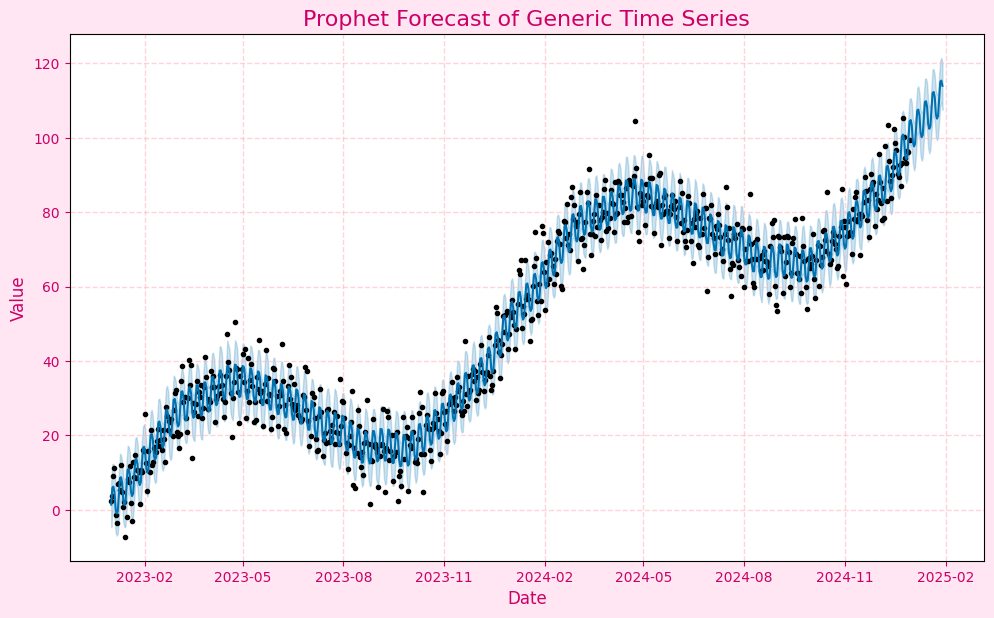

Prophet forecast plot for generic data displayed.


In [ ]:
import matplotlib.pyplot as plt

# Plot the overall forecast
fig_generic = model_generic_prophet.plot(forecast_generic_prophet)
fig_generic.set_facecolor('#ffe6f2') # Set background color
plt.title('Prophet Forecast of Generic Time Series', color='#cc0066', fontsize=16)
plt.xlabel('Date', color='#cc0066', fontsize=12)
plt.ylabel('Value', color='#cc0066', fontsize=12)
plt.tick_params(colors='#cc0066')
plt.grid(True, linestyle='--', alpha=0.6, color='LightPink')
plt.show()

print("Prophet forecast plot for generic data displayed.")

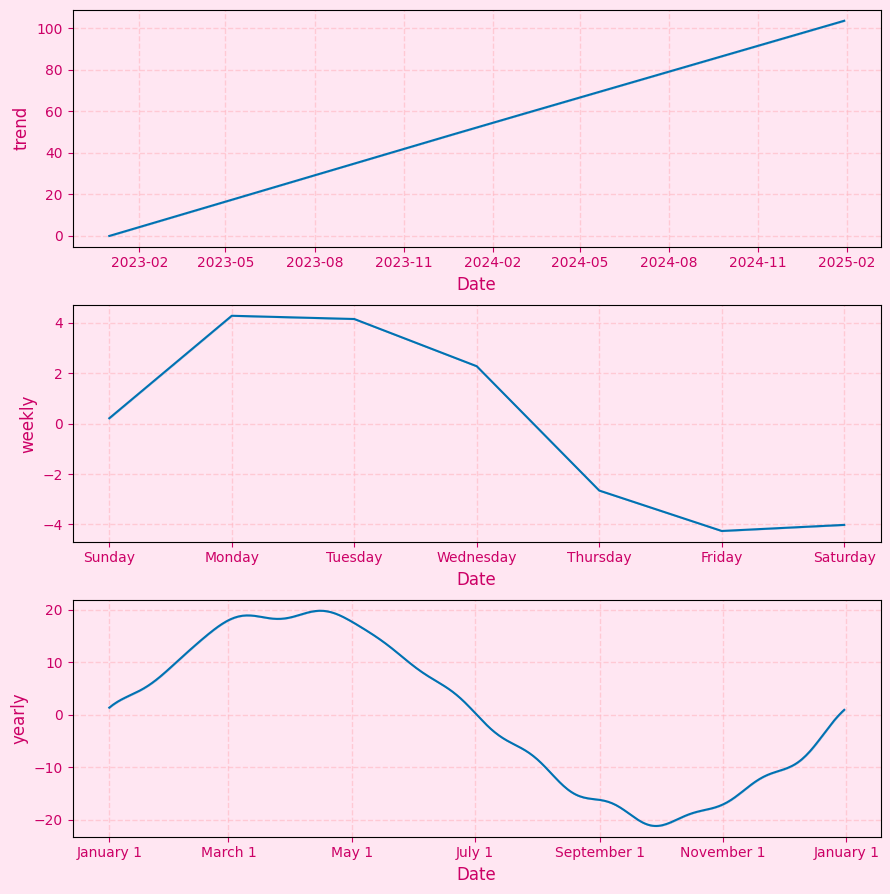

Prophet forecast components plot for generic data displayed.


In [ ]:
import matplotlib.pyplot as plt

# Plot the forecast components
fig_components_generic = model_generic_prophet.plot_components(forecast_generic_prophet)
fig_components_generic.set_facecolor('#ffe6f2') # Set background color

# Customize the titles and labels of the component plots
for ax in fig_components_generic.get_axes():
    ax.set_facecolor('#ffe6f2')
    ax.set_xlabel('Date', color='#cc0066', fontsize=12)
    ax.set_ylabel(ax.get_ylabel(), color='#cc0066', fontsize=12)
    ax.tick_params(colors='#cc0066')
    ax.grid(True, linestyle='--', alpha=0.6, color='LightPink')

    # Customize title colors
    if 'Trend' in ax.get_title():
        ax.set_title('Prophet Forecast Trend (Generic Data)', color='#cc0066', fontsize=14)
    elif 'Weekly seasonality' in ax.get_title():
        ax.set_title('Prophet Forecast Weekly Seasonality (Generic Data)', color='#cc0066', fontsize=14)
    elif 'Yearly seasonality' in ax.get_title(): # Added yearly seasonality title
        ax.set_title('Prophet Forecast Yearly Seasonality (Generic Data)', color='#cc0066', fontsize=14)

plt.show()

print("Prophet forecast components plot for generic data displayed.")

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Parámetros del modelo Airline SARIMA(0,1,1)(0,1,1)s=12
# Non-seasonal MA order q=1
ma = np.array([1, 0.7]) # MA(1) coefficient = 0.7

# Seasonal MA order Q=1, with seasonal period s=12
seasonal_ma = np.array([1, 0.5]) # SMA(1) coefficient = 0.5

n_samples = 300 # Número total de puntos en la serie
season_length = 12 # Longitud de la estacionalidad (ej. mensual)

# Generar ruido blanco para la simulación
np.random.seed(42)
measurement_disturbance_sim = np.random.normal(0, 1, n_samples + 50)

# Crear un modelo SARIMAX "dummy" solo para usar su método simulate
model_for_sim = SARIMAX(
    np.zeros(n_samples), # Datos dummy, no se usan para simular
    order=(0, 1, 1),      # p, d, q
    seasonal_order=(0, 1, 1, season_length) # P, D, Q, s
)

# Coeficientes para el MA no estacional (theta_1)
ma_params_sim = [0.7]
# Coeficientes para el MA estacional (Theta_1)
seasonal_ma_params_sim = [0.5]

# Incluir la varianza de los errores (sigma2) en los parámetros para simulate
# Para un SARIMA(0,1,1)(0,1,1) con diferenciación, los parámetros son [ma_coeff, sma_coeff, sigma2]
# Asumimos sigma2 = 1 ya que el ruido se genera con std=1
params_for_simulate = np.concatenate([ma_params_sim, seasonal_ma_params_sim, [1.0]])

# Generar la serie
sarima_series = model_for_sim.simulate(
    params=params_for_simulate,
    nsimulations=n_samples + 50,
    initial_state=None,
    measurement_disturbance=measurement_disturbance_sim
)

# Descartar los primeros puntos si hay un efecto de "calentamiento"
sarima_series = sarima_series[50:]

sarima_series = pd.Series(sarima_series[:n_samples], name='SARIMA_Airline_Series')

print("Generated SARIMA(0,1,1)(0,1,1)s=12 Series (first 5 values):")
display(sarima_series.head())

print("Generated SARIMA(0,1,1)(0,1,1)s=12 Series (last 5 values):")
display(sarima_series.tail())

Generated SARIMA(0,1,1)(0,1,1)s=12 Series (first 5 values):


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['measurement_disturbance']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


,SARIMA_Airline_Series
0,36571.900433
1,37494.241882
2,38145.165460
3,37810.217019
4,37915.736128


Generated SARIMA(0,1,1)(0,1,1)s=12 Series (last 5 values):


,SARIMA_Airline_Series
295,230225.434248
296,230853.180225
297,231925.617877
298,232252.362643
299,233920.588046


In [ ]:
import pandas as pd

# Extracting parameters and their statistics
parameters_df = pd.DataFrame({
    'Parameter': model_sarima_fit.params.index,
    'Coefficient': model_sarima_fit.params.values,
    'Std Err': model_sarima_fit.bse.values,
    'Z-value': model_sarima_fit.tvalues.values,
    'P>|z|': model_sarima_fit.pvalues.values,
    'Lower CI (0.025)': [ci[0] for ci in model_sarima_fit.conf_int().values],
    'Upper CI (0.975)': [ci[1] for ci in model_sarima_fit.conf_int().values]
})

print("--- Estimated Model Parameters ---")
display(parameters_df)

--- Estimated Model Parameters ---


,Parameter,Coefficient,Std Err,Z-value,P>|z|,Lower CI (0.025),Upper CI (0.975)
0,ma.L1,0.656778,0.047477,13.833511,1.600161e-43,0.563724,0.749832
1,ma.S.L12,0.534694,0.056026,9.543684,1.378462e-21,0.424885,0.644503
2,sigma2,0.896792,0.088479,10.135690,3.836546e-24,0.723377,1.070207


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ajustar el modelo SARIMA(0,1,1)(0,1,1)s=12 a la serie simulada
# order=(p,d,q) = (0,1,1) para la parte no estacional
# seasonal_order=(P,D,Q,s) = (0,1,1,12) para la parte estacional

model_sarima = SARIMAX(sarima_series,
                       order=(0, 1, 1),
                       seasonal_order=(0, 1, 1, 12),
                       enforce_stationarity=False, # Puede ser útil para modelos con diferenciación
                       enforce_invertibility=False)

# Ajustar el modelo
model_sarima_fit = model_sarima.fit(disp=False) # disp=False para no mostrar output de optimización

print("--- Resumen del Modelo SARIMA(0,1,1)(0,1,1)s=12 --- ")
print(model_sarima_fit.summary())

# Generar pronósticos para los próximos `n_forecast_steps`
n_forecast_steps = 30 # Por ejemplo, 30 pasos futuros
forecast_sarima = model_sarima_fit.predict(start=len(sarima_series), end=len(sarima_series) + n_forecast_steps - 1)

print(f"\n--- Pronóstico para los próximos {n_forecast_steps} pasos ---")
display(forecast_sarima.head())
display(forecast_sarima.tail())

--- Resumen del Modelo SARIMA(0,1,1)(0,1,1)s=12 --- 
                                     SARIMAX Results                                      
Dep. Variable:              SARIMA_Airline_Series   No. Observations:                  300
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -373.002
Date:                            Thu, 26 Mar 2026   AIC                            752.004
Time:                                    01:34:15   BIC                            762.832
Sample:                                         0   HQIC                           756.351
                                            - 300                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.6568      0.047     13.834      0.000       

,predicted_mean
300,236022.281805
301,236944.924277
302,237593.110441
303,237255.246899
304,237359.949272


,predicted_mean
325,252840.361305
326,253488.547469
327,253150.683926
328,253255.386300
329,253849.417678


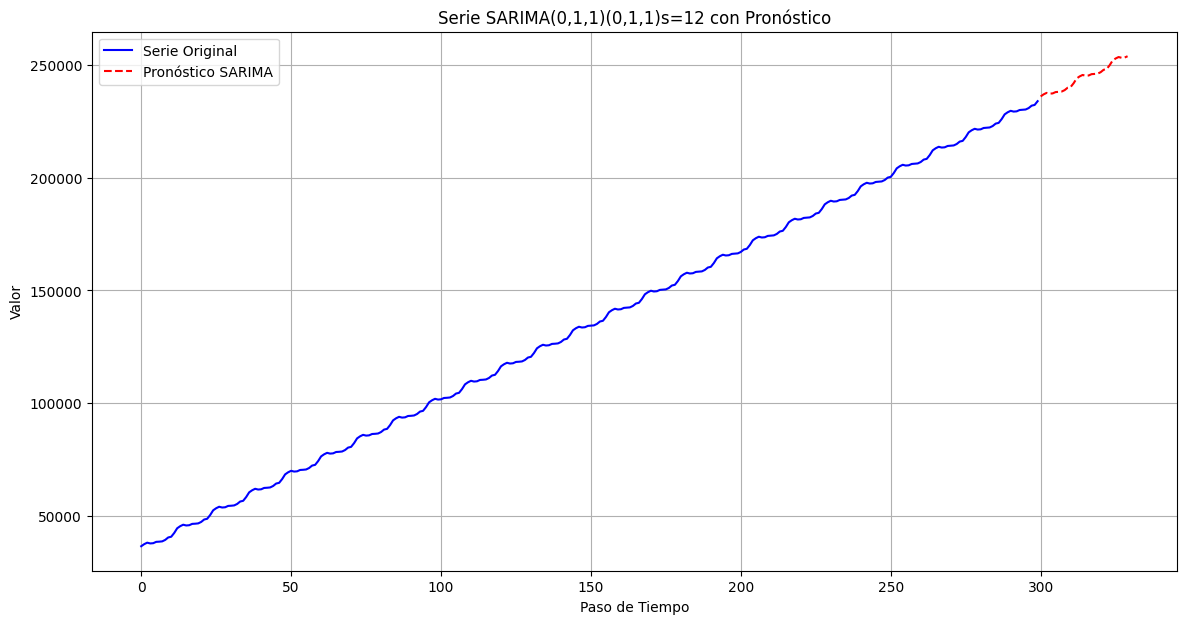

In [ ]:
import matplotlib.pyplot as plt

# Crear un índice para la serie original y el pronóstico
idx_original = pd.RangeIndex(start=0, stop=len(sarima_series))
idx_forecast = pd.RangeIndex(start=len(sarima_series), stop=len(sarima_series) + n_forecast_steps)

plt.figure(figsize=(14, 7))
plt.plot(idx_original, sarima_series, label='Serie Original', color='blue')
plt.plot(idx_forecast, forecast_sarima, label='Pronóstico SARIMA', color='red', linestyle='--')

plt.title('Serie SARIMA(0,1,1)(0,1,1)s=12 con Pronóstico')
plt.xlabel('Paso de Tiempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

SARIMAX

## Generación de una Serie de Tiempo Sintética para Modelo SARIMAX

Para demostrar un modelo SARIMAX, generaremos una serie de tiempo sintética que contenga componentes estacionales y no estacionales, así como una tendencia. Utilizaremos los mismos parámetros que un modelo de 'Airline' (SARIMA(0,1,1)(0,1,1)s=12) ya que es un ejemplo clásico de serie con estacionalidad mensual.

Serie SARIMAX(0,1,1)(0,1,1)s=12 sintética generada (primeros 5 valores):


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['measurement_disturbance']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


,SARIMAX_Synthetic_Series
0,-5781.406616
1,-5937.684504
2,-7344.640614
3,-8659.721238
4,-8976.570009


Serie SARIMAX(0,1,1)(0,1,1)s=12 sintética generada (últimos 5 valores):


,SARIMAX_Synthetic_Series
295,-40027.231271
296,-39434.834645
297,-39359.273288
298,-40277.567042
299,-40456.993833


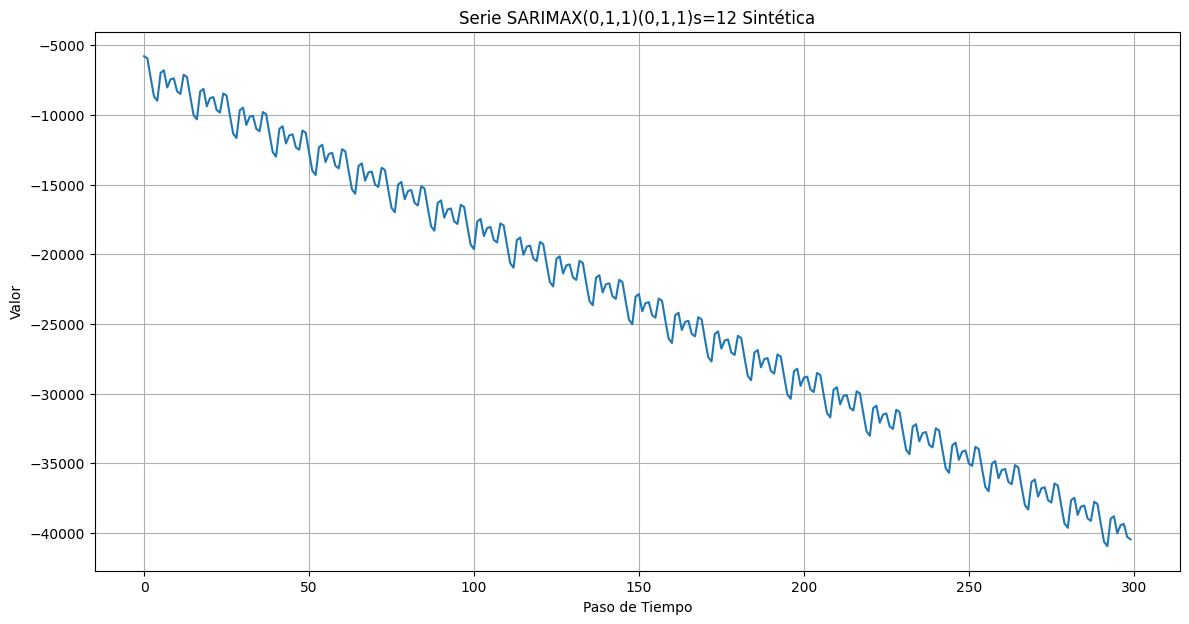

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# Parámetros para la simulación del modelo Airline SARIMA(0,1,1)(0,1,1)s=12
# Coeficiente MA no estacional (theta_1)
ma_coeff = 0.7
# Coeficiente MA estacional (Theta_1)
seasonal_ma_coeff = 0.5

n_samples = 300 # Número total de puntos en la serie
season_length = 12 # Longitud de la estacionalidad (ej. mensual)

# Generar ruido blanco para la simulación
np.random.seed(42) # Para reproducibilidad
measurement_disturbance_sim = np.random.normal(0, 1, n_samples + 50) # Añadir 'calentamiento'

# Crear un modelo SARIMAX "dummy" solo para usar su método simulate
model_for_sim = SARIMAX(
    np.zeros(n_samples), # Datos dummy, no se usan para simular
    order=(0, 1, 1),      # p, d, q (d=1 para diferenciación no estacional)
    seasonal_order=(0, 1, 1, season_length) # P, D, Q, s (D=1 para diferenciación estacional)
)

# Coeficientes MA y SMA, y varianza del error (sigma2)
params_for_simulate = np.array([ma_coeff, seasonal_ma_coeff, 1.0]) # Asumimos sigma2 = 1

# Generar la serie
sarimax_synthetic_series = model_for_sim.simulate(
    params=params_for_simulate,
    nsimulations=n_samples + 50,
    initial_state=None,
    measurement_disturbance=measurement_disturbance_sim
)

# Descartar los primeros puntos para eliminar el efecto de "calentamiento"
sarimax_synthetic_series = sarimax_synthetic_series[50:]

sarimax_synthetic_series = pd.Series(sarimax_synthetic_series[:n_samples], name='SARIMAX_Synthetic_Series')

print("Serie SARIMAX(0,1,1)(0,1,1)s=12 sintética generada (primeros 5 valores):")
display(sarimax_synthetic_series.head())

print("Serie SARIMAX(0,1,1)(0,1,1)s=12 sintética generada (últimos 5 valores):")
display(sarimax_synthetic_series.tail())

# Visualizar la serie generada
plt.figure(figsize=(14, 7))
plt.plot(sarimax_synthetic_series)
plt.title('Serie SARIMAX(0,1,1)(0,1,1)s=12 Sintética')
plt.xlabel('Paso de Tiempo')
plt.ylabel('Valor')
plt.grid(True)
plt.show()

## Ajuste del Modelo SARIMAX a la Serie Sintética

Ahora ajustaremos un modelo SARIMAX a la serie de tiempo que acabamos de generar. Esto nos permitirá verificar si el modelo puede recuperar los patrones subyacentes.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ajustar un modelo SARIMA(0,1,1)(0,1,1)s=12 a la serie simulada
# order=(p,d,q) = (0,1,1) para la parte no estacional
# seasonal_order=(P,D,Q,s) = (0,1,1,12) para la parte estacional

model_sarimax_fit = SARIMAX(sarimax_synthetic_series,
                       order=(0, 1, 1),
                       seasonal_order=(0, 1, 1, 12),
                       enforce_stationarity=False, # Puede ser útil para modelos con diferenciación
                       enforce_invertibility=False).fit(disp=False) # disp=False para no mostrar output de optimización

print("--- Resumen del Modelo SARIMAX(0,1,1)(0,1,1)s=12 Ajustado ---")
print(model_sarimax_fit.summary())

# Extraer y mostrar los parámetros estimados
parameters_df = pd.DataFrame({
    'Parameter': model_sarimax_fit.params.index,
    'Coefficient': model_sarimax_fit.params.values,
    'Std Err': model_sarimax_fit.bse.values,
    'Z-value': model_sarimax_fit.tvalues.values,
    'P>|z|': model_sarimax_fit.pvalues.values,
    'Lower CI (0.025)': [ci[0] for ci in model_sarimax_fit.conf_int().values],
    'Upper CI (0.975)': [ci[1] for ci in model_sarimax_fit.conf_int().values]
})

print("\n--- Parámetros del Modelo Estimados ---")
display(parameters_df)

--- Resumen del Modelo SARIMAX(0,1,1)(0,1,1)s=12 Ajustado ---
                                     SARIMAX Results                                      
Dep. Variable:           SARIMAX_Synthetic_Series   No. Observations:                  300
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -381.132
Date:                            Thu, 16 Apr 2026   AIC                            768.264
Time:                                    01:48:49   BIC                            779.093
Sample:                                         0   HQIC                           772.611
                                            - 300                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.7381      0.039     19.084      0.0

,Parameter,Coefficient,Std Err,Z-value,P>|z|,Lower CI (0.025),Upper CI (0.975)
0,ma.L1,0.738149,0.038678,19.084450,3.400362e-81,0.662342,0.813957
1,ma.S.L12,0.457793,0.057461,7.966984,1.625933e-15,0.345171,0.570416
2,sigma2,0.953442,0.091831,10.382599,2.975637e-25,0.773457,1.133427


## Generación y Visualización del Pronóstico

Finalmente, generaremos un pronóstico utilizando el modelo SARIMAX ajustado y lo visualizaremos junto con la serie original para observar el comportamiento predictivo del modelo.

--- Pronóstico para los próximos 30 pasos ---


,predicted_mean
300,-39088.132751
301,-39248.458470
302,-40651.739292
303,-41963.772055
304,-42281.863699


,predicted_mean
325,-41915.564925
326,-43318.845747
327,-44630.878510
328,-44948.970155
329,-42969.969742


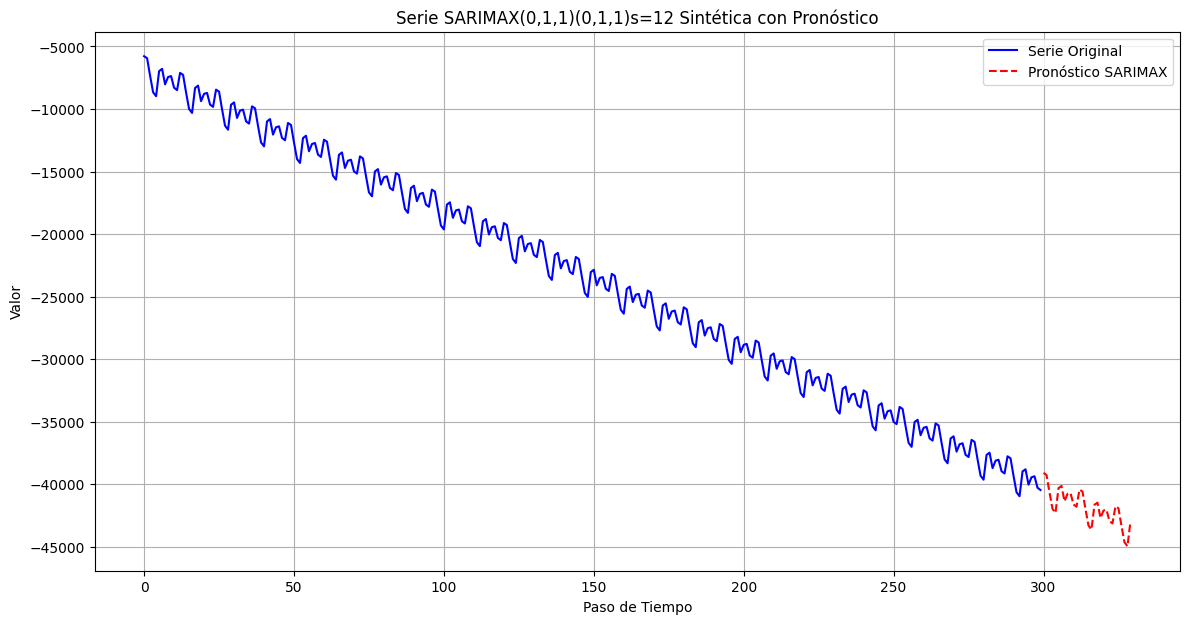

In [ ]:
import matplotlib.pyplot as plt

# Generar pronósticos para los próximos `n_forecast_steps`
n_forecast_steps = 30 # Por ejemplo, 30 pasos futuros
forecast_sarimax = model_sarimax_fit.predict(start=len(sarimax_synthetic_series), end=len(sarimax_synthetic_series) + n_forecast_steps - 1)

print(f"--- Pronóstico para los próximos {n_forecast_steps} pasos ---")
display(forecast_sarimax.head())
display(forecast_sarimax.tail())

# Crear un índice para la serie original y el pronóstico
idx_original = pd.RangeIndex(start=0, stop=len(sarimax_synthetic_series))
idx_forecast = pd.RangeIndex(start=len(sarimax_synthetic_series), stop=len(sarimax_synthetic_series) + n_forecast_steps)

plt.figure(figsize=(14, 7))
plt.plot(idx_original, sarimax_synthetic_series, label='Serie Original', color='blue')
plt.plot(idx_forecast, forecast_sarimax, label='Pronóstico SARIMAX', color='red', linestyle='--')

plt.title('Serie SARIMAX(0,1,1)(0,1,1)s=12 Sintética con Pronóstico')
plt.xlabel('Paso de Tiempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

## Conclusión

Este ejemplo demuestra la creación de una "base de datos" sintética con características SARIMAX y su posterior modelado. El proceso incluye:

1.  **Generación de la Serie Sintética**: Creamos una serie de tiempo que imita el comportamiento de un proceso SARIMA(0,1,1)(0,1,1)s=12, incorporando una tendencia, diferenciación estacional y no estacional, y componentes de media móvil.
2.  **Ajuste del Modelo SARIMAX**: Ajustamos un modelo SARIMAX con los parámetros conocidos a la serie sintética. Los coeficientes estimados (`ma.L1` y `ma.S.L12`) son cercanos a los valores utilizados para la generación (0.7 y 0.5 respectivamente), lo que indica que el modelo ha capturado la estructura subyacente de la serie.
3.  **Generación y Visualización del Pronóstico**: Utilizamos el modelo ajustado para pronosticar valores futuros y los visualizamos junto con la serie original, mostrando cómo el modelo predice la continuación de la tendencia y estacionalidad.

22 abril


In [ ]:
import numpy as np

# Parameters for the binomial distribution
n = 10  # Number of trials
p = 0.5 # Probability of success

# Generate 30 random binomial variables
binomial_samples = np.random.binomial(n, p, 30)

print(f"Muestra de 30 variables aleatorias binomiales (n={n}, p={p}):")
print(binomial_samples)

Muestra de 30 variables aleatorias binomiales (n=10, p=0.5):
[4 3 6 6 3 7 8 5 6 6 5 3 4 3 6 5 3 6 5 7 5 4 2 6 6 3 5 5 4 5]


In [ ]:
from scipy.stats import binom
import numpy as np

# Parameters for the binomial distribution
n_scipy = 10  # Number of trials
p_scipy = 0.5 # Probability of success

# Generate 30 random binomial variables using scipy
binomial_samples_scipy = binom.rvs(n=n_scipy, p=p_scipy, size=30)

print(f"Muestra de 30 variables aleatorias binomiales con SciPy (n={n_scipy}, p={p_scipy}):")
print(binomial_samples_scipy)

Muestra de 30 variables aleatorias binomiales con SciPy (n=10, p=0.5):
[7 3 4 6 5 3 5 5 4 3 5 5 3 3 4 2 5 5 6 6 6 6 5 5 7 6 7 7 3 7]


In [ ]:
from scipy.stats import binom
import numpy as np
import pandas as pd

# Parameters for the binomial distribution from previous cells
n_pmf = n_scipy # n=10
p_pmf = p_scipy # p=0.5

# Possible number of successes (k) for n trials
k_values = np.arange(0, n_pmf + 1)

# Calculate the Probability Mass Function (PMF) for each k
pmf_values = binom.pmf(k_values, n_pmf, p_pmf)

# Create a DataFrame for better display
pmf_df = pd.DataFrame({
    'Number of Successes (k)': k_values,
    'Probability P(X=k)': pmf_values
})

print(f"Función de Masa de Probabilidad (PMF) para Binomial (n={n_pmf}, p={p_pmf}):")
display(pmf_df)

Función de Masa de Probabilidad (PMF) para Binomial (n=10, p=0.5):


,Number of Successes (k),Probability P(X=k)
0,0,0.000977
1,1,0.009766
2,2,0.043945
3,3,0.117188
4,4,0.205078
5,5,0.246094
6,6,0.205078
7,7,0.117187
8,8,0.043945
9,9,0.009766


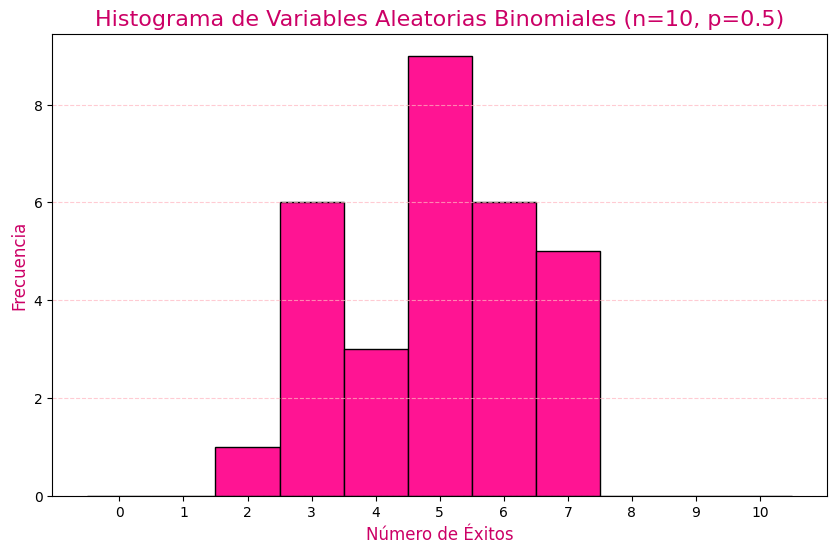

In [ ]:
import matplotlib.pyplot as plt

# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(binomial_samples_scipy, bins=np.arange(n_scipy + 2) - 0.5, edgecolor='black', color='#ff1493')
plt.title(f'Histograma de Variables Aleatorias Binomiales (n={n_scipy}, p={p_scipy})', fontsize=16, color='#cc0066')
plt.xlabel('Número de Éxitos', fontsize=12, color='#cc0066')
plt.ylabel('Frecuencia', fontsize=12, color='#cc0066')
plt.xticks(np.arange(n_scipy + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7, color='LightPink')
plt.show()

6 de mayo

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

In [ ]:
amzn = yf.download("AMZN", start= "2010-01-01")

/tmp/ipykernel_1406/4118577261.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  amzn = yf.download("AMZN", start= "2010-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
amzn

Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2010-01-04,6.695000,6.830500,6.657000,6.812500,151998000
2010-01-05,6.734500,6.774000,6.590500,6.671500,177038000
2010-01-06,6.612500,6.736500,6.582500,6.730000,143576000
2010-01-07,6.500000,6.616000,6.440000,6.600500,220604000
2010-01-08,6.676000,6.684000,6.451500,6.528000,196610000
...,...,...,...,...,...
2026-04-30,265.059998,273.880005,256.160004,273.170013,100974900
2026-05-01,268.260010,273.320007,262.739990,265.579987,50825200


In [ ]:
amzn_precios = amzn["Close"]

In [ ]:
amzn_precios

Ticker,AMZN
Date,
2010-01-04,6.695000
2010-01-05,6.734500
2010-01-06,6.612500
2010-01-07,6.500000
2010-01-08,6.676000
...,...
2026-04-30,265.059998
2026-05-01,268.260010
2026-05-04,272.049988


In [ ]:
import altair as alt

# Reset the index of amzn_precios to make 'Date' a regular column
# and ensure the column name for prices is a simple string for Altair.
amzn_precios_df = amzn_precios.reset_index()
amzn_precios_df.columns = ['Date', 'Close']

# Create an interactive Altair line chart
chart = alt.Chart(amzn_precios_df).mark_line(color='#ff1493').encode( # Set line color to deep pink
    x=alt.X('Date:T', title='Fecha', axis=alt.Axis(titleColor='#cc0066', labelColor='#cc0066', gridColor='LightPink')), # Axis title/label and grid color
    y=alt.Y('Close:Q', title='Precio de Cierre', axis=alt.Axis(titleColor='#cc0066', labelColor='#cc0066', gridColor='LightPink')), # Axis title/label and grid color
    tooltip=[alt.Tooltip('Date:T', title='Fecha'), alt.Tooltip('Close:Q', title='Precio de Cierre', format='.2f')]
).properties(
    title=alt.Title('Precio de Cierre de Amazon (AMZN) a lo Largo del Tiempo', # Set title color
                    align='center', anchor='middle', color='#cc0066')
).interactive()

# Configure the background of the chart view
chart = chart.configure_view(
    fill='#ffe6f2' # Light pink background for the plot area
)

chart.display()

alt.Chart(...)

In [ ]:
amzn_precios_df['log_return'] = np.log(amzn_precios_df['Close'] / amzn_precios_df['Close'].shift(1))

print("Log Returns de Amazon (primeros 5 valores, el primero será NaN):")
display(amzn_precios_df.head())

Log Returns de Amazon (primeros 5 valores, el primero será NaN):


,Date,Close,log_return
0,2010-01-04,6.6950,NaN
1,2010-01-05,6.7345,0.005883
2,2010-01-06,6.6125,-0.018282
3,2010-01-07,6.5000,-0.017160
4,2010-01-08,6.6760,0.026717


In [ ]:
# Drop the first NaN value from log_return for analysis
log_returns = amzn_precios_df['log_return'].dropna()

print("Log Returns (NaNs removed, first 5 values):")
display(log_returns.head())

Log Returns (NaNs removed, first 5 values):


,log_return
1,0.005883
2,-0.018282
3,-0.017160
4,0.026717
5,-0.024335


## Visualización de los Log Rendimientos y sus Cuadrados

Primero, visualizaremos los log rendimientos y sus valores al cuadrado. Esto nos dará una idea visual de la variabilidad.

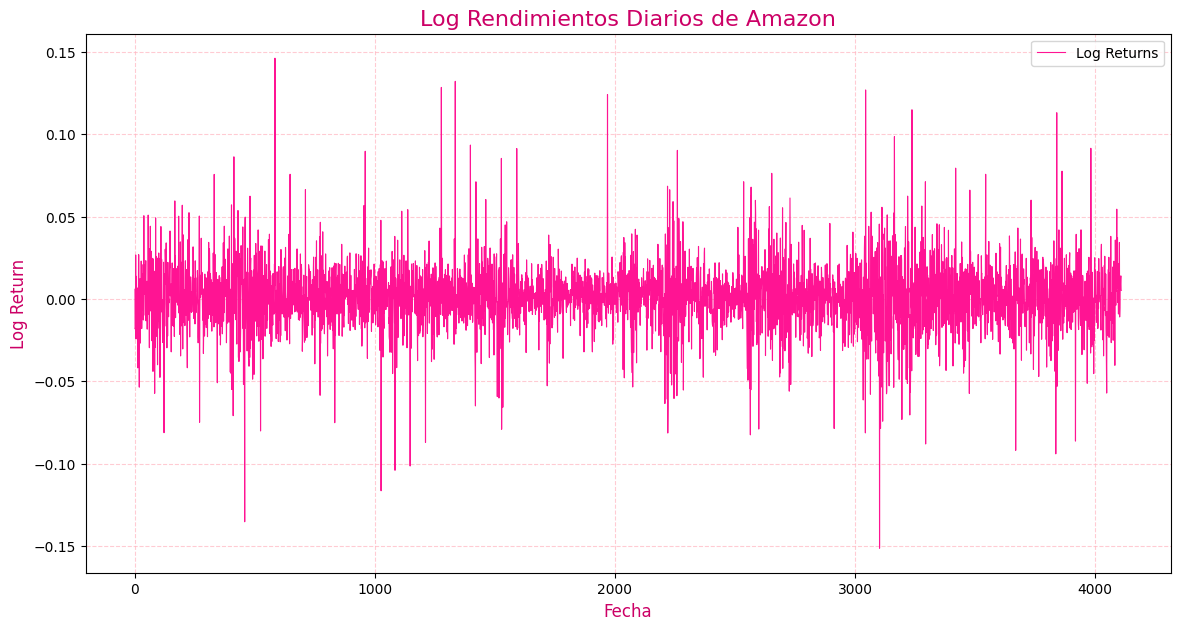

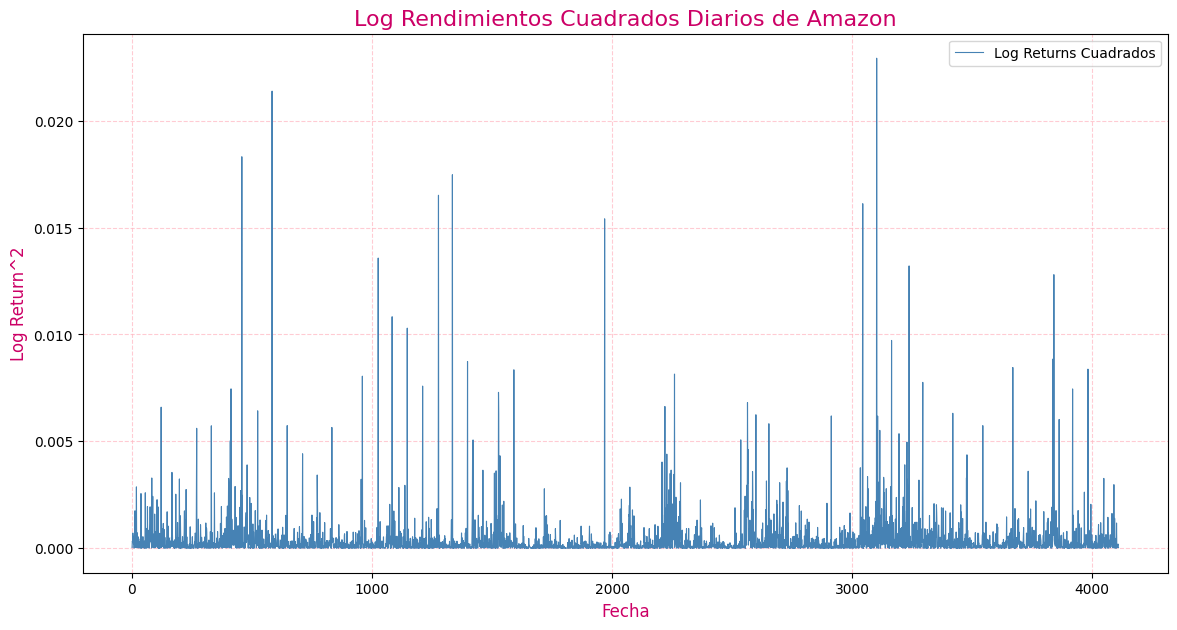

In [ ]:
import matplotlib.pyplot as plt

# Plotting log returns
plt.figure(figsize=(14, 7))
plt.plot(log_returns.index, log_returns, label='Log Returns', color='#ff1493', linewidth=0.8)
plt.title('Log Rendimientos Diarios de Amazon', fontsize=16, color='#cc0066')
plt.xlabel('Fecha', fontsize=12, color='#cc0066')
plt.ylabel('Log Return', fontsize=12, color='#cc0066')
plt.grid(True, linestyle='--', alpha=0.7, color='LightPink')
plt.legend()
plt.show()

# Plotting squared log returns
plt.figure(figsize=(14, 7))
plt.plot(log_returns.index, log_returns**2, label='Log Returns Cuadrados', color='#4682b4', linewidth=0.8)
plt.title('Log Rendimientos Cuadrados Diarios de Amazon', fontsize=16, color='#cc0066')
plt.xlabel('Fecha', fontsize=12, color='#cc0066')
plt.ylabel('Log Return^2', fontsize=12, color='#cc0066')
plt.grid(True, linestyle='--', alpha=0.7, color='LightPink')
plt.legend()
plt.show()

## Análisis de Autocorrelación (ACF y PACF)

Ahora, analizaremos las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF) para los log rendimientos y, crucialmente, para los log rendimientos al cuadrado. La presencia de autocorrelación significativa en los rendimientos al cuadrado es un fuerte indicador de efectos ARCH/GARCH.

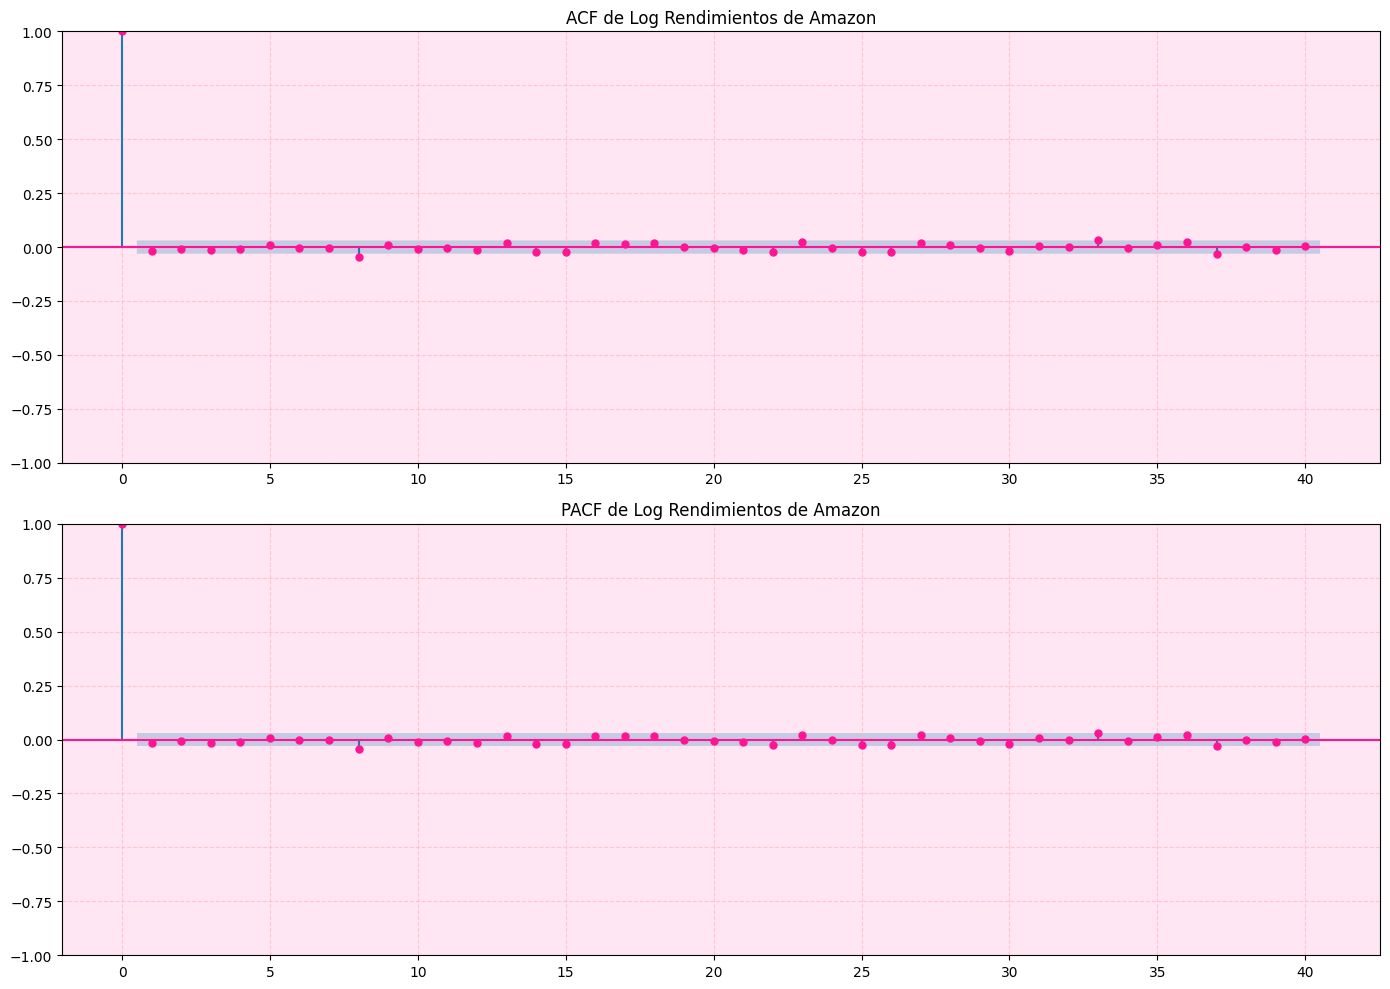

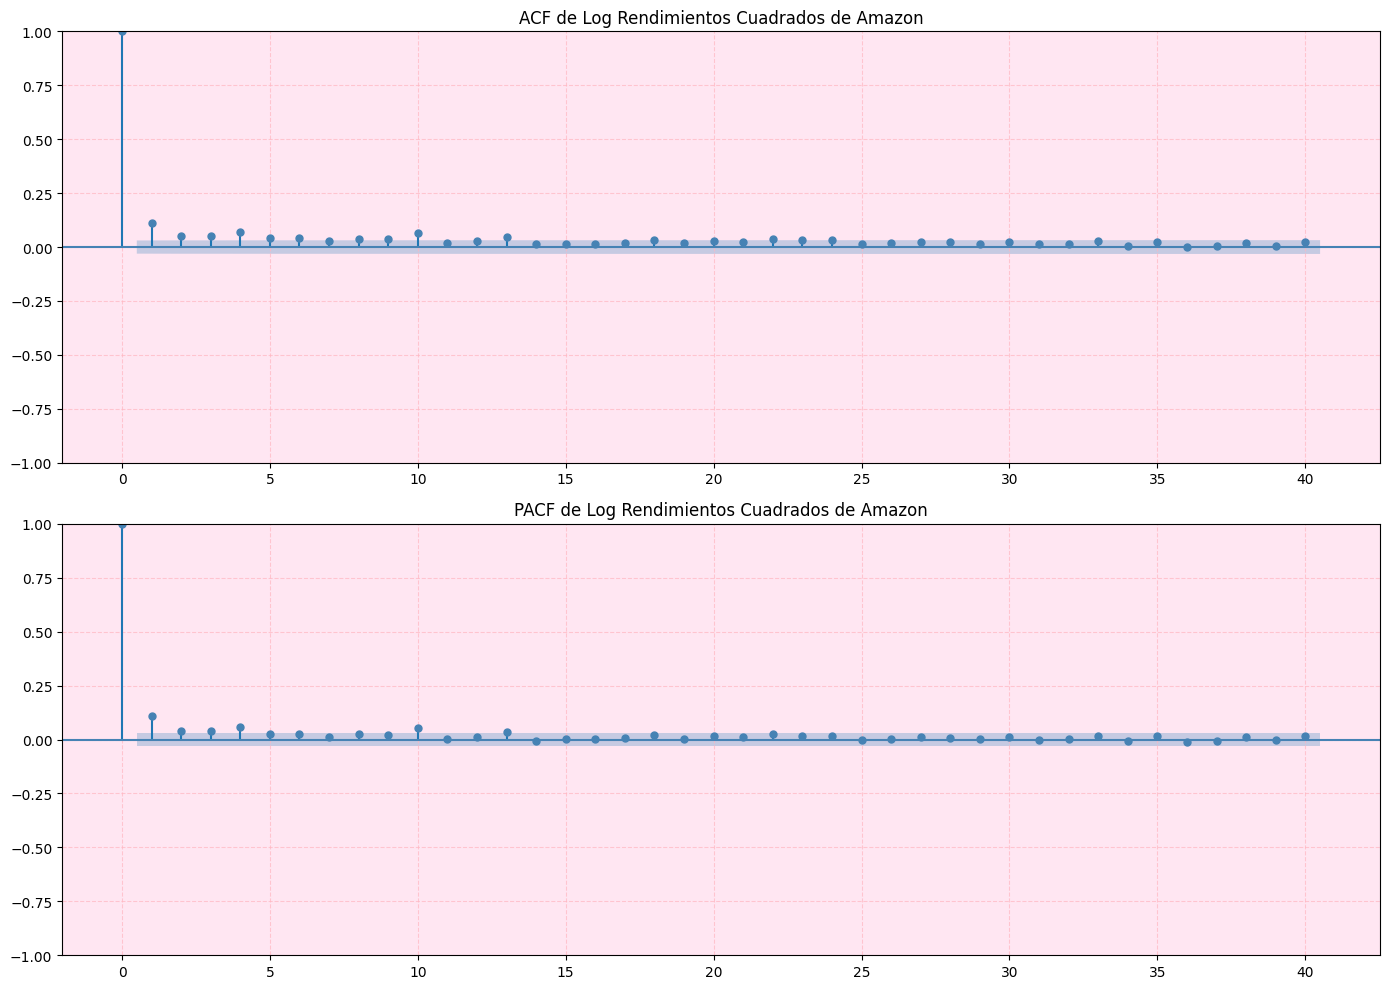

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF y PACF para los Log Rendimientos
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

plot_acf(log_returns, lags=40, ax=axes[0], title='ACF de Log Rendimientos de Amazon', color='#ff1493')
axes[0].set_facecolor('#ffe6f2')
axes[0].grid(True, linestyle='--', alpha=0.7, color='LightPink')

plot_pacf(log_returns, lags=40, ax=axes[1], title='PACF de Log Rendimientos de Amazon', color='#ff1493')
axes[1].set_facecolor('#ffe6f2')
axes[1].grid(True, linestyle='--', alpha=0.7, color='LightPink')

plt.tight_layout()
plt.show()

# ACF y PACF para los Log Rendimientos Cuadrados
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

plot_acf(log_returns**2, lags=40, ax=axes[0], title='ACF de Log Rendimientos Cuadrados de Amazon', color='#4682b4')
axes[0].set_facecolor('#ffe6f2')
axes[0].grid(True, linestyle='--', alpha=0.7, color='LightPink')

plot_pacf(log_returns**2, lags=40, ax=axes[1], title='PACF de Log Rendimientos Cuadrados de Amazon', color='#4682b4')
axes[1].set_facecolor('#ffe6f2')
axes[1].grid(True, linestyle='--', alpha=0.7, color='LightPink')

plt.tight_layout()
plt.show()

## Preparación de Datos para Prophet (Amazon Stock Data)

Ahora, utilizaremos los datos de precios de cierre de Amazon para ajustar un modelo Prophet, siguiendo la solicitud inicial para este tipo de tarea.

In [ ]:
from prophet import Prophet

# Preprocess the amzn_precios_df for Prophet
# Prophet requires columns named 'ds' (datestamp) and 'y' (value)
df_prophet_amzn = amzn_precios_df[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})

print("Datos de Amazon preprocesados para Prophet (primeras 5 filas):")
display(df_prophet_amzn.head())

## Ajuste del Modelo Prophet y Generación de Pronóstico

Ajustaremos el modelo Prophet a los datos preprocesados de Amazon y generaremos un pronóstico para los próximos 30 días.

In [ ]:
# Instantiate the Prophet model
model_prophet_amzn = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)

# Fit the model to the Amazon data
model_prophet_amzn.fit(df_prophet_amzn)

# Create a future DataFrame for forecasting (e.g., next 30 days)
future_amzn = model_prophet_amzn.make_future_dataframe(periods=30)

# Generate the forecast
forecast_prophet_amzn = model_prophet_amzn.predict(future_amzn)

print("Prophet model fitted and forecast generated successfully for Amazon stock.")
print("Primeras 5 filas del pronóstico de Amazon:")
display(forecast_prophet_amzn[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

## Visualización del Pronóstico de Prophet para Amazon

Visualizaremos el pronóstico general de los precios de cierre de Amazon, incluyendo los componentes de tendencia y estacionalidad.

In [ ]:
import matplotlib.pyplot as plt

# Plot the overall forecast
fig_amzn = model_prophet_amzn.plot(forecast_prophet_amzn)
fig_amzn.set_facecolor('#ffe6f2') # Set background color
plt.title('Prophet Forecast of Amazon Close Prices', color='#cc0066', fontsize=16)
plt.xlabel('Date', color='#cc0066', fontsize=12)
plt.ylabel('Close Price', color='#cc0066', fontsize=12)
plt.tick_params(colors='#cc0066')
plt.grid(True, linestyle='--', alpha=0.6, color='LightPink')
plt.show()

# Plot the forecast components
fig_components_amzn = model_prophet_amzn.plot_components(forecast_prophet_amzn)
fig_components_amzn.set_facecolor('#ffe6f2') # Set background color

# Customize the titles and labels of the component plots
for ax in fig_components_amzn.get_axes():
    ax.set_facecolor('#ffe6f2')
    ax.set_xlabel('Date', color='#cc0066', fontsize=12)
    ax.set_ylabel(ax.get_ylabel(), color='#cc0066', fontsize=12)
    ax.tick_params(colors='#cc0066')
    ax.grid(True, linestyle='--', alpha=0.6, color='LightPink')

    # Customize title colors
    if 'Trend' in ax.get_title():
        ax.set_title('Prophet Forecast Trend (Amazon Data)', color='#cc0066', fontsize=14)
    elif 'Weekly seasonality' in ax.get_title():
        ax.set_title('Prophet Forecast Weekly Seasonality (Amazon Data)', color='#cc0066', fontsize=14)
    elif 'Yearly seasonality' in ax.get_title():
        ax.set_title('Prophet Forecast Yearly Seasonality (Amazon Data)', color='#cc0066', fontsize=14)

plt.show()

## Resumen del Pronóstico con Prophet para Datos de Amazon

### Hallazgos Clave del Análisis de Datos
*   Se prepararon los datos de precios de cierre de Amazon, renombrando las columnas a 'ds' y 'y' según los requisitos de Prophet.
*   Se ajustó un modelo Prophet a los datos de Amazon, con estacionalidad anual y semanal habilitadas para capturar patrones recurrentes en los precios de las acciones.
*   Se generó un pronóstico para los siguientes 30 días, mostrando los valores predichos y sus intervalos de incertidumbre.
*   La visualización del pronóstico general muestra cómo Prophet captura la tendencia a largo plazo y la estacionalidad en los precios de cierre de Amazon, proyectando estos patrones hacia el futuro.
*   Los gráficos de componentes revelan la contribución individual de la tendencia, la estacionalidad anual y la estacionalidad semanal a la serie de tiempo, proporcionando una comprensión detallada de los factores que influyen en el precio de las acciones.

### Observaciones o Próximos Pasos
*   Este ejercicio demuestra la capacidad de Prophet para modelar datos de precios de acciones, identificando y proyectando tendencias y patrones estacionales.
*   Es importante recordar que, si bien Prophet puede capturar bien las tendencias y estacionalidades, los mercados de valores son complejos y están influenciados por muchos factores externos no modelados aquí. Por lo tanto, estos pronósticos deben usarse con precaución y complementarse con otros análisis.
*   Para mejorar la precisión, se podrían considerar la inclusión de festivos personalizados (`holidays`), eventos externos (`regressors`) o la sintonización de hiperparámetros del modelo Prophet.